<a href="https://colab.research.google.com/github/Rashed17a/MScFE-560-Financial-Markets/blob/main/Project-1/technical-code/Group_Work_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 560 FINANCIAL MARKETS

In [ ]:
# %matplotlib inline
%config InlineBackend.figure_format = "retina"

In [ ]:
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
sns.set_theme(context="talk", style="whitegrid",
              palette="colorblind", color_codes=True,
              rc={"figure.figsize": [10, 5]})

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the visualization
sns.set(style="whitegrid")

# Portfolio 1:  Income stocks

In [ ]:
# Define the assets for the selected income stocks
assets = ['NVDA', 'CI', 'NFLX']

In [ ]:
# Define the start and end date for fetching historical data
start_date = '2020-01-01'
end_date = '2023-01-01'

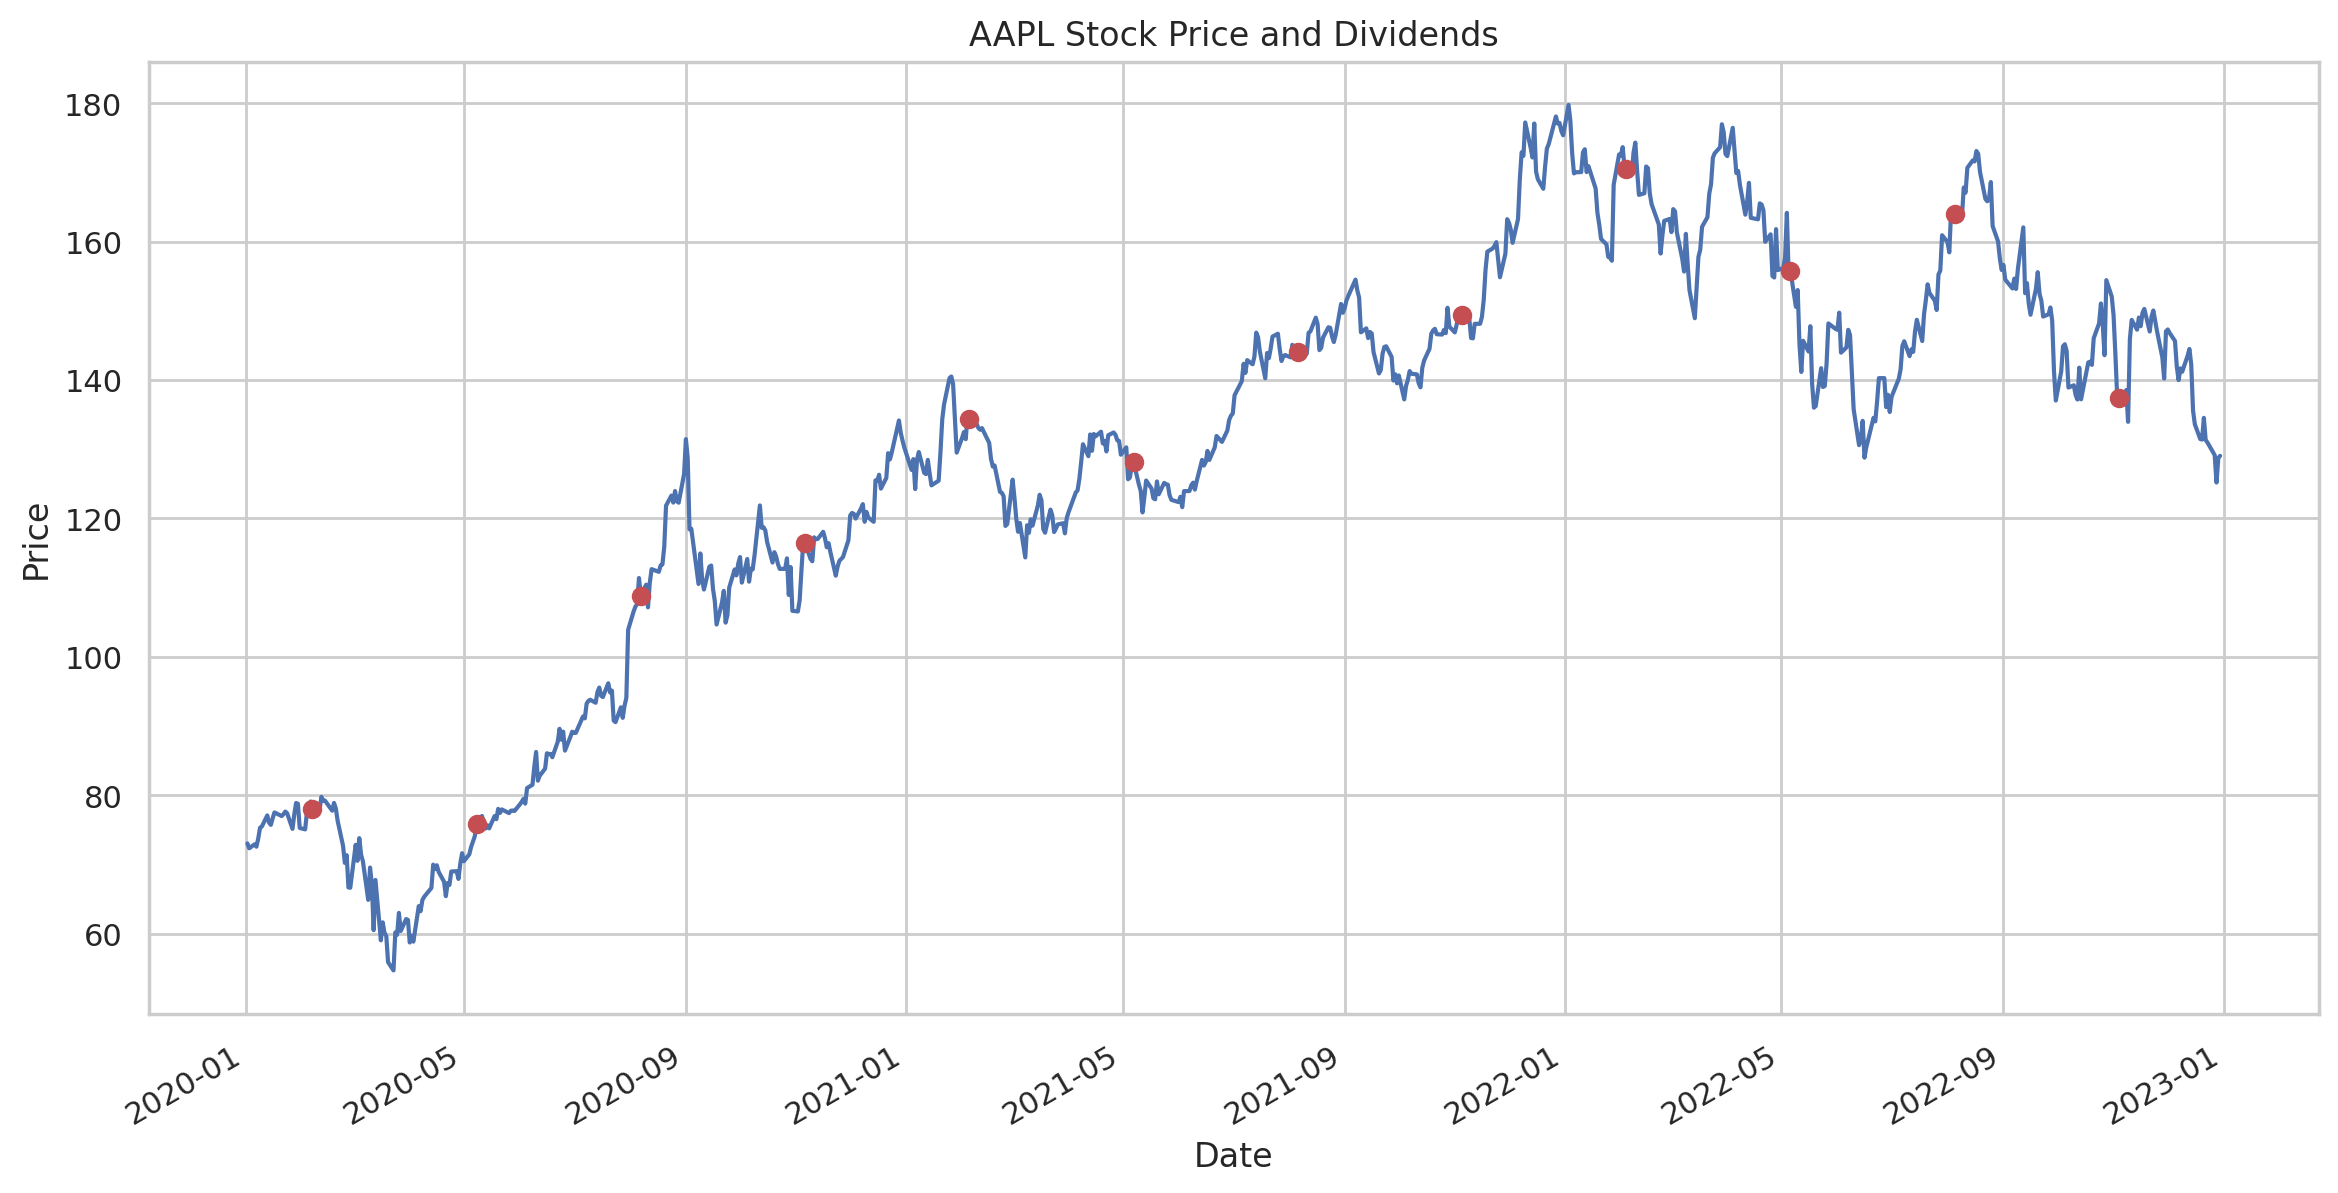

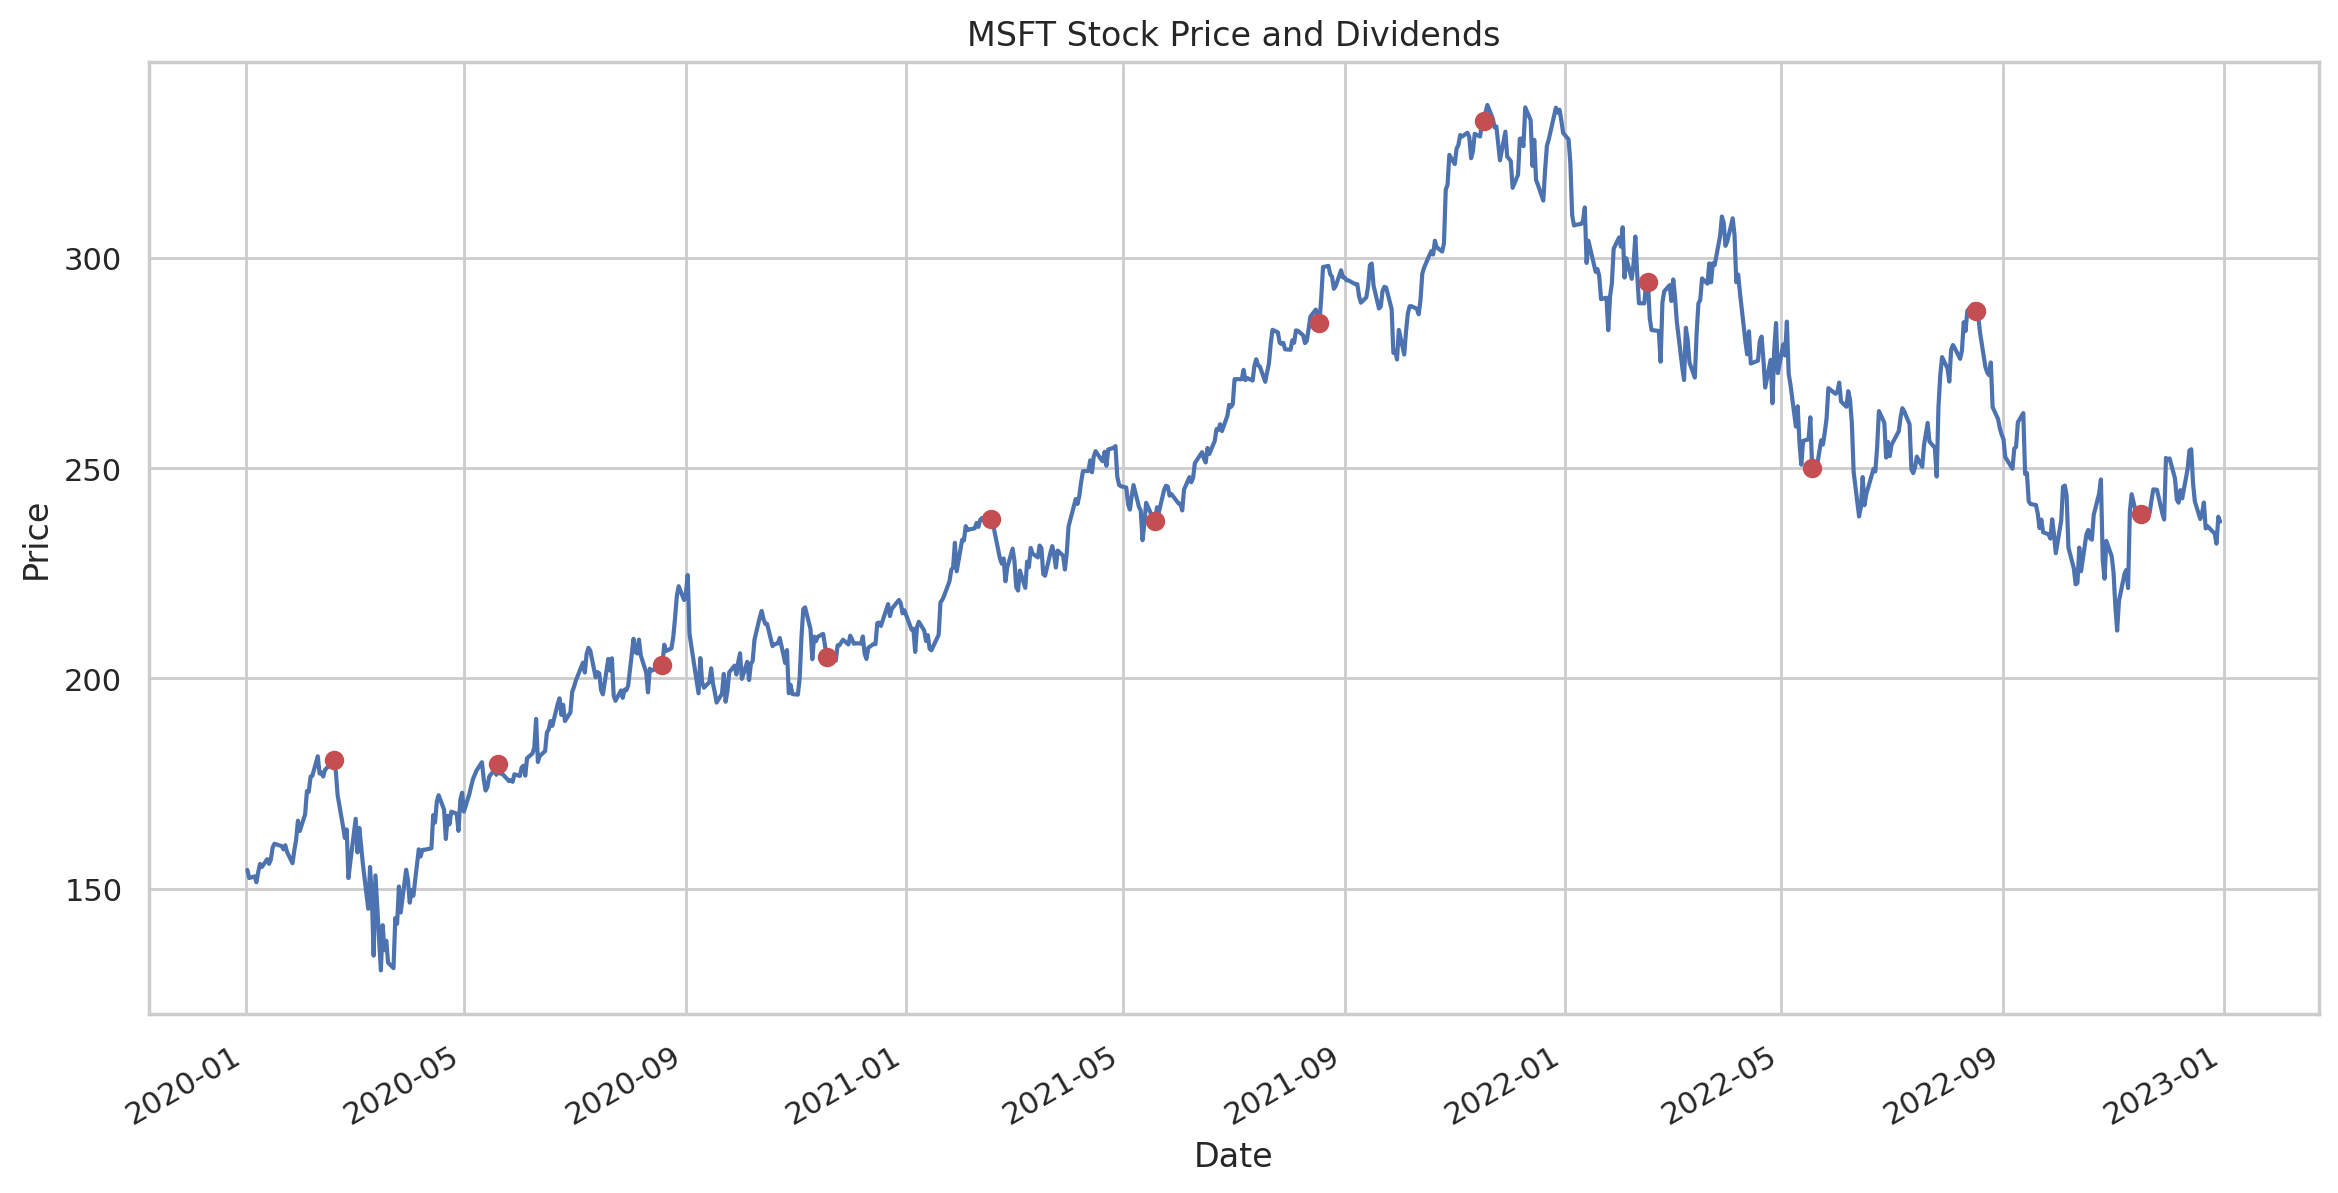

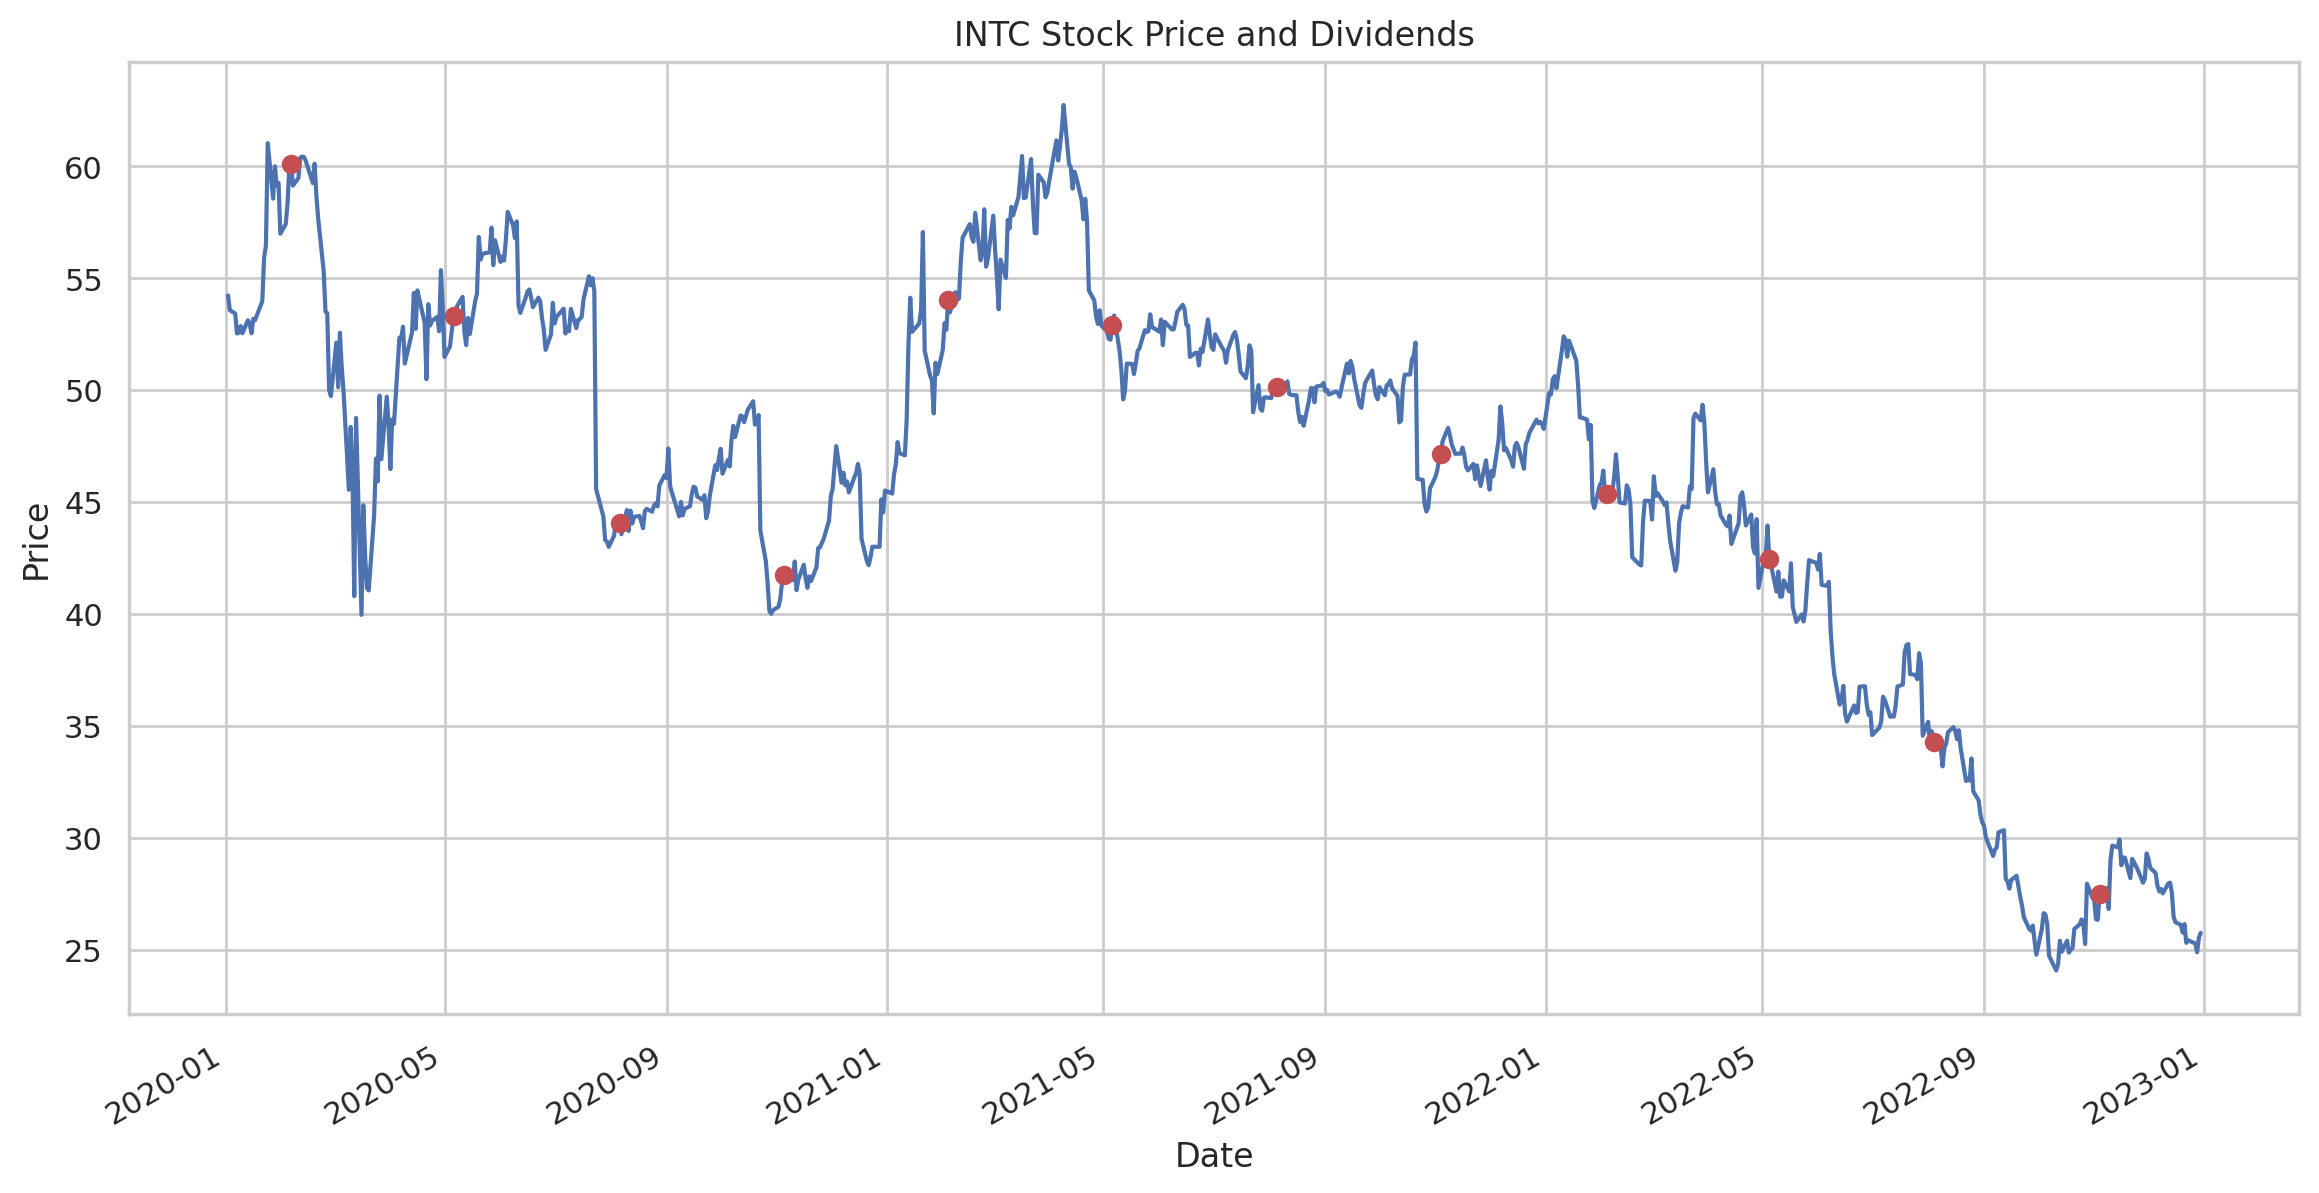

In [ ]:
# Fetch historical data including dividends
stock_data = {ticker: yf.Ticker(ticker) for ticker in assets}
hist_data = {ticker: data.history(start=start_date, end=end_date) for ticker, data in stock_data.items()}
dividends_data = {ticker: data.dividends for ticker, data in stock_data.items()}

# Plot the adjusted closing prices and annotate dividends
for ticker, data in hist_data.items():
    # Plot the historical data
    plt.figure(figsize=(14, 7))
    data['Close'].plot(title=f"{ticker} Stock Price and Dividends")

    # Get the dividends for the ticker
    dividends = dividends_data[ticker]

    # Annotate each dividend payment with a red dot at the price close
    for date in dividends.index:
        plt.plot(date, data['Close'].loc[date], 'ro')

    plt.ylabel('Price')
    plt.show()

In [ ]:
# Fetch historical adjusted closing prices
data = yf.download(assets, start=start_date, end=end_date)['Adj Close']

[*********************100%%**********************]  3 of 3 completed


In [ ]:
data.head()

Ticker,AAPL,INTC,MSFT
Date,,,
2020-01-02,73.059418,54.226269,154.493820
2020-01-03,72.349136,53.566708,152.570129
2020-01-06,72.925636,53.415192,152.964462
2020-01-07,72.582649,52.523899,151.569778
2020-01-08,73.750237,52.559547,153.984055


In [ ]:
# Calculate retunrns (Simple returns)
returns = (data / data.shift(1)) - 1
returns.tail()

Ticker,AAPL,INTC,MSFT
Date,,,
2022-12-23,-0.002798,0.004621,0.002267
2022-12-27,-0.013878,-0.005749,-0.007414
2022-12-28,-0.030685,-0.015420,-0.010255
2022-12-29,0.028324,0.026233,0.027630
2022-12-30,0.002469,0.008394,-0.004938


In [ ]:
# Annualize the returns and volatility if the data is daily
trading_days = 252
annual_returns = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)

In [ ]:
# Create a DataFrame to display results
annual_statistics = pd.DataFrame({
    'Annual Return': annual_returns,
    'Annual Volatility': annual_volatility
})

# Display the DataFrame
print(annual_statistics)

        Annual Return  Annual Volatility
Ticker                                  
AAPL         0.258011           0.369334
INTC        -0.159204           0.420764
MSFT         0.203655           0.347571


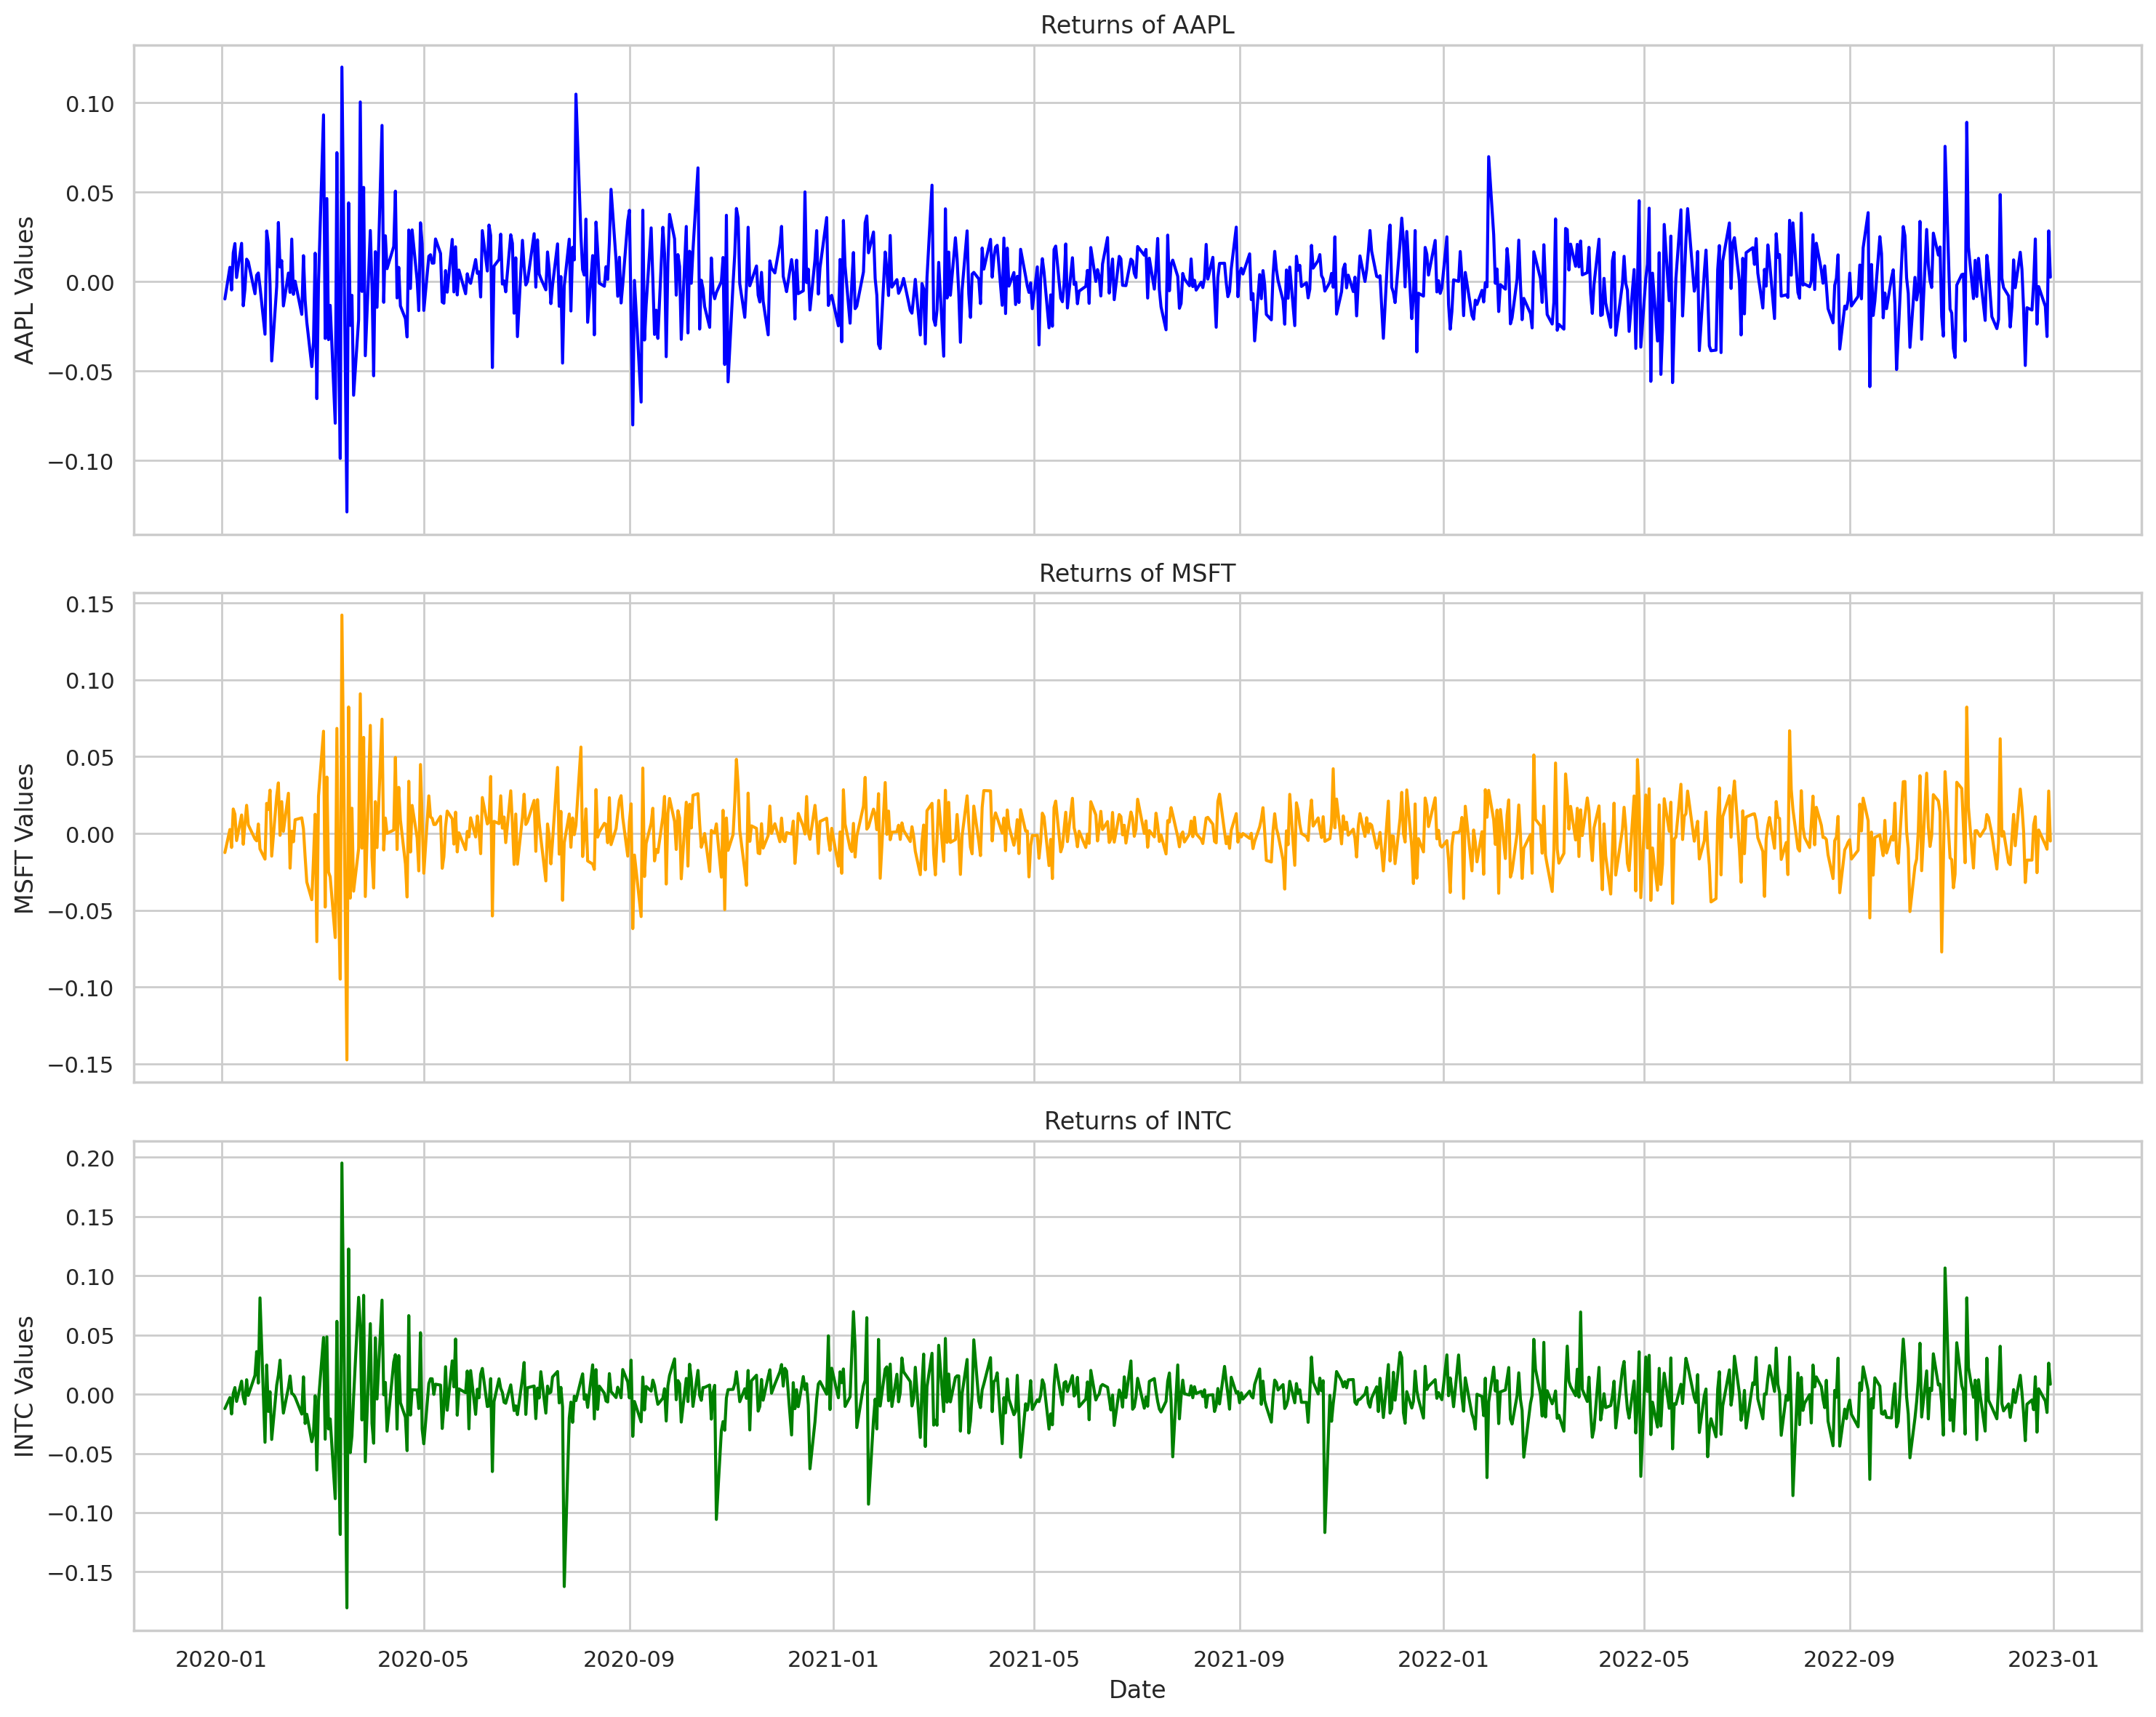

In [ ]:
# Create a figure with a 3x1 grid of subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Line plot for AAPL
sns.lineplot(ax=axes[0], x=returns.index, y=returns['AAPL'], color='blue')
axes[0].set_title('Returns of AAPL')
axes[0].set_ylabel('AAPL Values')

# Line plot for MSFT
sns.lineplot(ax=axes[1], x=returns.index, y=returns['MSFT'], color='orange')
axes[1].set_title('Returns of MSFT')
axes[1].set_ylabel('MSFT Values')

# Line plot for INTC
sns.lineplot(ax=axes[2], x=returns.index, y=returns['INTC'], color='green')
axes[2].set_title('Returns of INTC')
axes[2].set_ylabel('INTC Values')

# Automatically adjust subplot params
plt.tight_layout()

# Show the plot
plt.show()

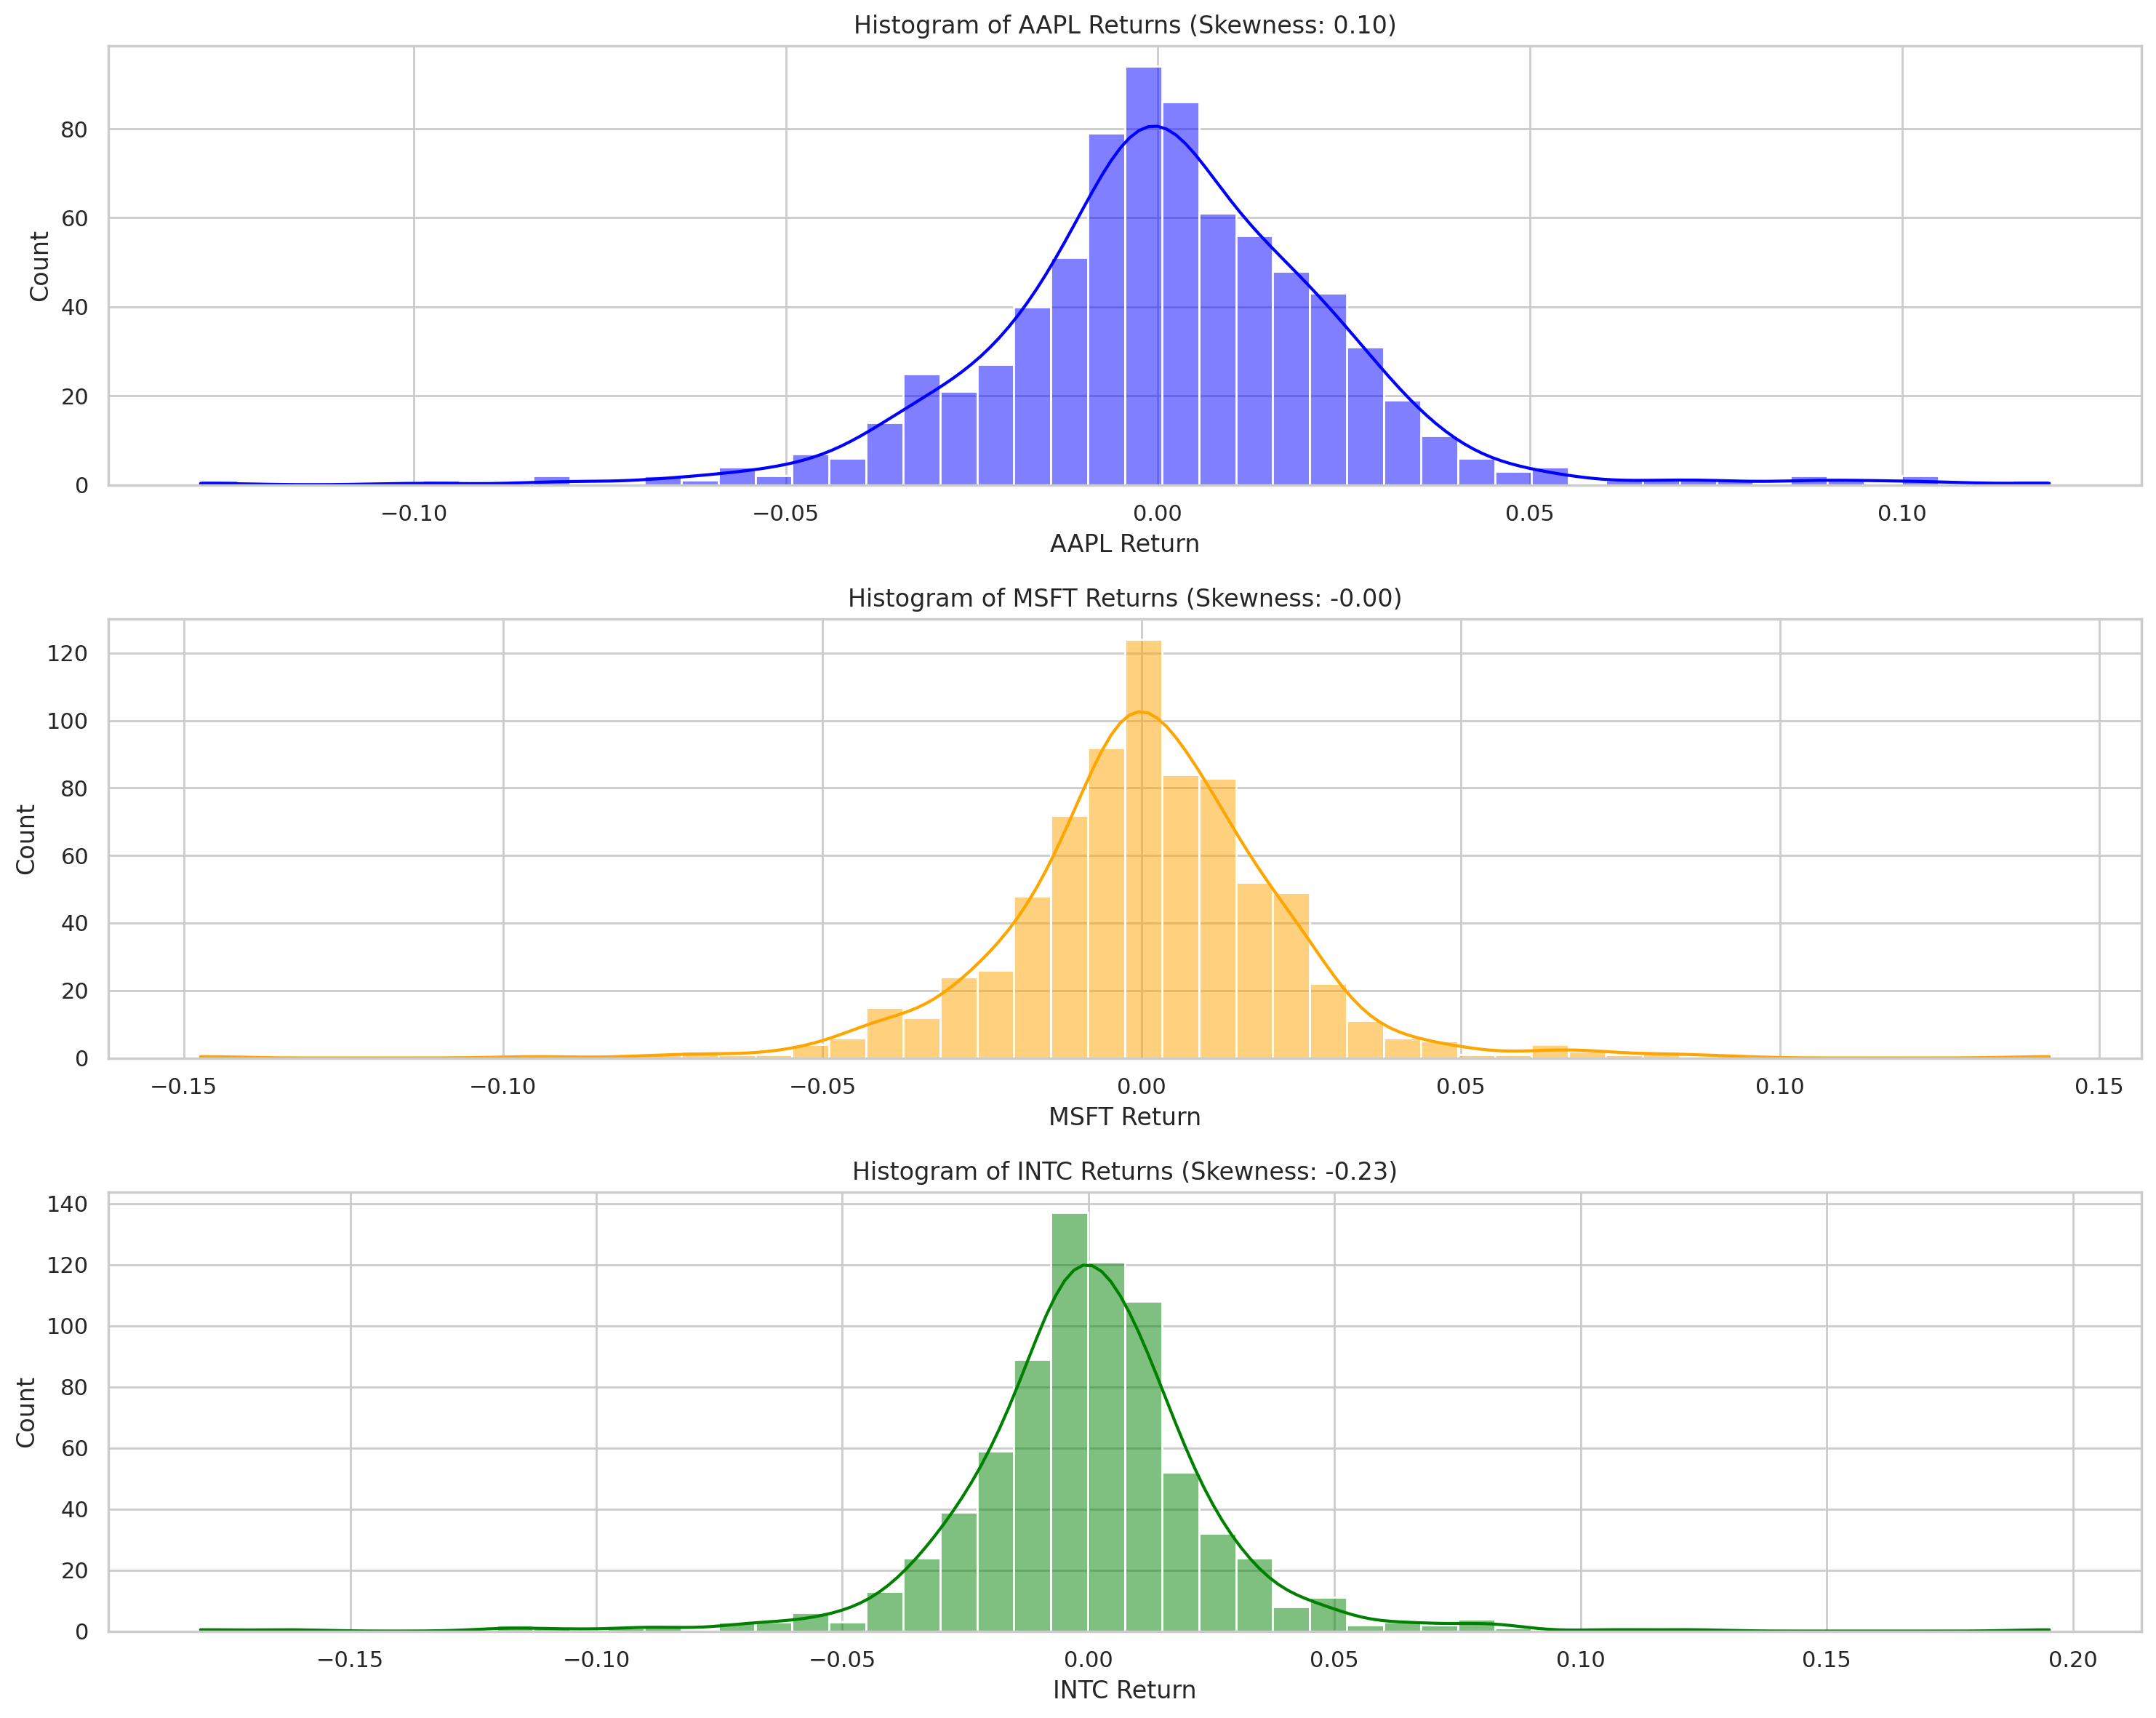

In [ ]:
# Create a figure with a 3x1 grid of subplots for histograms
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Histogram and skewness for AAPL
sns.histplot(returns['AAPL'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Histogram of AAPL Returns (Skewness: {returns["AAPL"].skew():.2f})')
axes[0].set_xlabel('AAPL Return')

# Histogram and skewness for MSFT
sns.histplot(returns['MSFT'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title(f'Histogram of MSFT Returns (Skewness: {returns["MSFT"].skew():.2f})')
axes[1].set_xlabel('MSFT Return')

# Histogram and skewness for INTC
sns.histplot(returns['INTC'], bins=50, kde=True, ax=axes[2], color='green')
axes[2].set_title(f'Histogram of INTC Returns (Skewness: {returns["INTC"].skew():.2f})')
axes[2].set_xlabel('INTC Return')

# Automatically adjust subplot params
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
skewness = returns.skew()  # Skewness of daily returns
kurtosis = returns.kurtosis()  # Kurtosis of daily returns

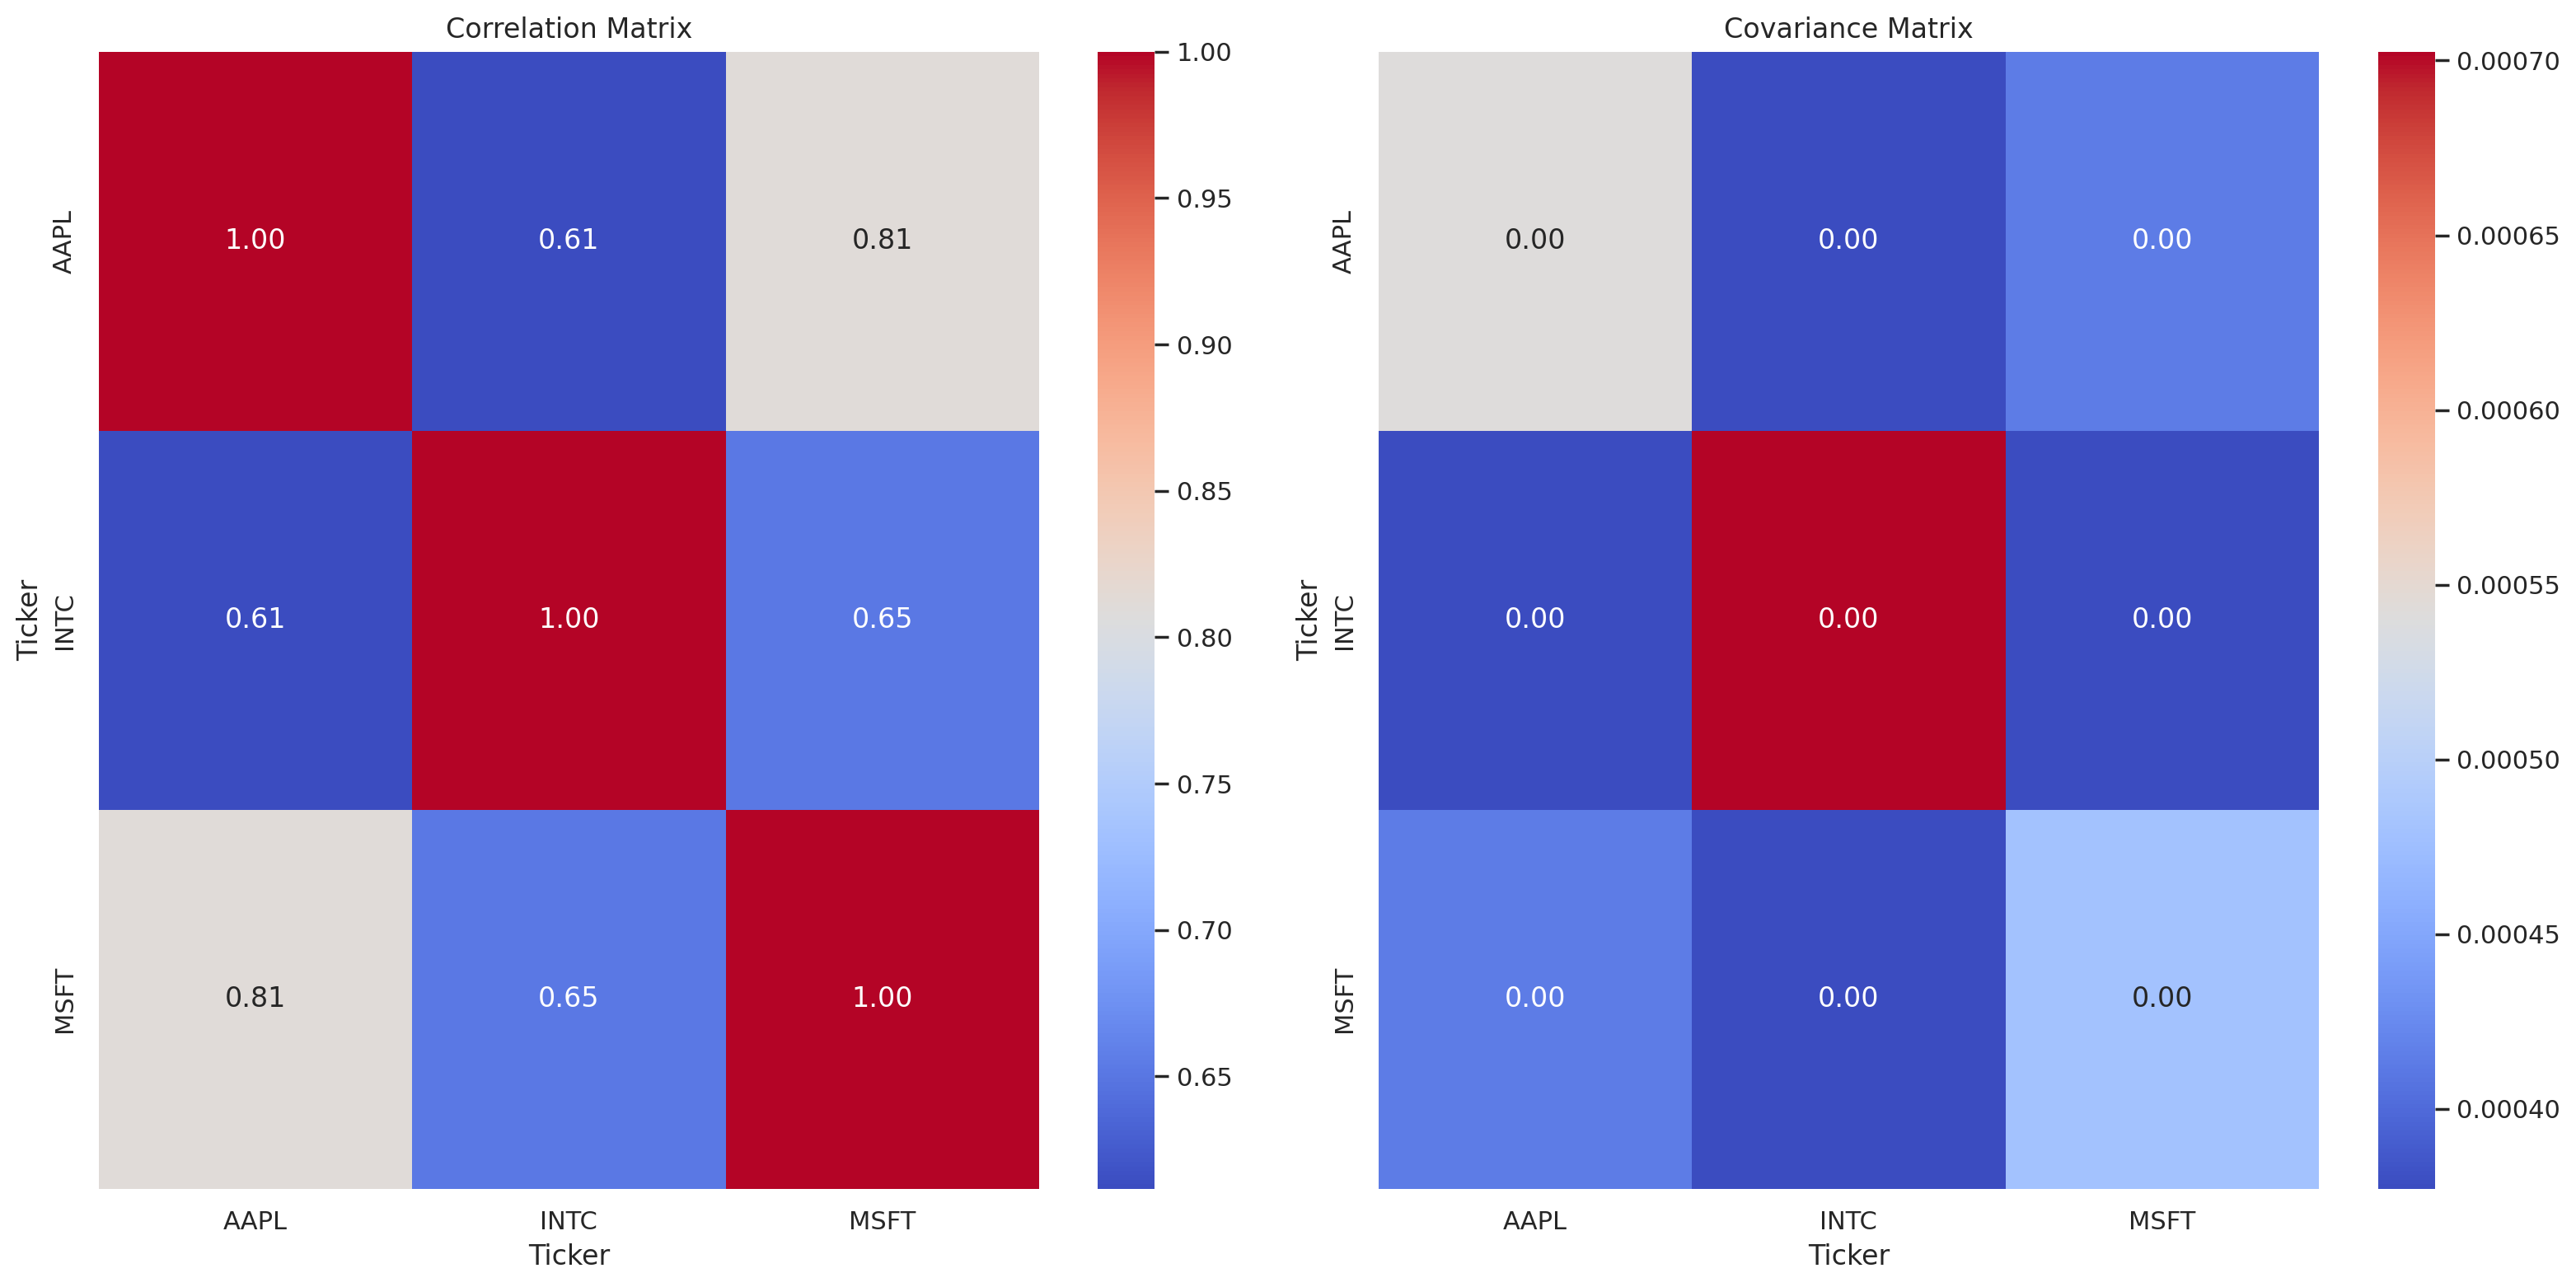

In [ ]:
# Calculate correlations and covariances among the stocks
correlations = returns.corr()
covariances = returns.cov()

# Set up the matplotlib figure
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Draw the heatmap for correlations
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0])
ax[0].set_title('Correlation Matrix')

# Draw the heatmap for covariances
sns.heatmap(covariances, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1])
ax[1].set_title('Covariance Matrix')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
returns.describe()

Ticker,AAPL,INTC,MSFT
count,755.000000,755.000000,755.000000
mean,0.001024,-0.000632,0.000808
std,0.023266,0.026506,0.021895
min,-0.128647,-0.180415,-0.147390
25%,-0.011103,-0.012179,-0.009685
50%,0.000613,-0.000374,0.000699
75%,0.014154,0.011732,0.012323
max,0.119808,0.195212,0.142169


In [ ]:
# Output the results
print("Average Return:\n", annual_returns)
print("\nVolatility:\n", annual_volatility)
print("\nSkewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)
print("\nCorrelations:\n", correlations)
print("\nCovariances:\n", covariances)

Average Return:
 Ticker
AAPL    0.258011
INTC   -0.159204
MSFT    0.203655
dtype: float64

Volatility:
 Ticker
AAPL    0.369334
INTC    0.420764
MSFT    0.347571
dtype: float64

Skewness:
 Ticker
AAPL    0.095036
INTC   -0.225997
MSFT   -0.001682
dtype: float64

Kurtosis:
 Ticker
AAPL     4.040120
INTC    10.560295
MSFT     6.422098
dtype: float64

Correlations:
 Ticker      AAPL      INTC      MSFT
Ticker                              
AAPL    1.000000  0.611718  0.811363
INTC    0.611718  1.000000  0.652042
MSFT    0.811363  0.652042  1.000000

Covariances:
 Ticker      AAPL      INTC      MSFT
Ticker                              
AAPL    0.000541  0.000377  0.000413
INTC    0.000377  0.000703  0.000378
MSFT    0.000413  0.000378  0.000479


In [ ]:
# Calculate log returns for each bonds
log_returns = np.log(data / data.shift(1))

# Drop the first row with NaN values that result from the shift operation
log_returns = log_returns.dropna()

# Show the tail of the log returns DataFrame
log_returns.tail()

Ticker,AAPL,INTC,MSFT
Date,,,
2022-12-23,-0.002802,0.004610,0.002264
2022-12-27,-0.013976,-0.005766,-0.007442
2022-12-28,-0.031166,-0.015540,-0.010308
2022-12-29,0.027931,0.025895,0.027255
2022-12-30,0.002466,0.008359,-0.004950


In [ ]:
# We create an Equally Weighted Portfolio
portfolio_value = 1000000
weights = np.array([1/len(assets)]*len(assets))
print(weights)

[0.33333333 0.33333333 0.33333333]


In [ ]:
historical_returns = (log_returns * weights).sum(axis =1)
print(historical_returns)

Date
2020-01-03   -0.011512
2020-01-06    0.002562
2020-01-07   -0.010234
2020-01-08    0.010813
2020-01-09    0.013005
                ...   
2022-12-23    0.001358
2022-12-27   -0.009061
2022-12-28   -0.019005
2022-12-29    0.027027
2022-12-30    0.001958
Length: 755, dtype: float64


In [ ]:
#We find the x-day Historical Returns
days = 5

range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2020-01-09    0.004634
2020-01-10    0.013323
2020-01-13    0.025448
2020-01-14    0.027898
2020-01-15    0.015045
                ...   
2022-12-23   -0.025291
2022-12-27   -0.021566
2022-12-28   -0.037877
2022-12-29   -0.027181
2022-12-30    0.002277
Length: 751, dtype: float64


In [ ]:
#We create a Covariance Matrix and calculate the portfolio standard deviation

cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [ ]:
cov_matrix

Ticker,AAPL,INTC,MSFT
Ticker,,,
AAPL,0.136283,0.095470,0.104582
INTC,0.095470,0.179872,0.095624
MSFT,0.104582,0.095624,0.121105


In [ ]:
#We calculate VaR at Different Confidence Levels

from scipy.stats import norm

confidence_levels = [0.90, 0.95, 0.99]

VaRs = []
for cl in confidence_levels:
    VaR = portfolio_value * portfolio_std_dev * norm.ppf(cl) * np.sqrt(days / 252)
    VaRs.append(VaR)

In [ ]:
#We get the VaR Results

print(f'{"Confidence Level":<20} {"Value at Risk":<20}')
print('-' * 40)

for cl, VaR in zip(confidence_levels, VaRs):
    print(f'{cl * 100:>6.0f}%: {"":<8} ${VaR:>10,.2f}')

Confidence Level     Value at Risk       
----------------------------------------
    90%:          $ 61,027.45
    95%:          $ 78,327.89
    99%:          $110,780.63


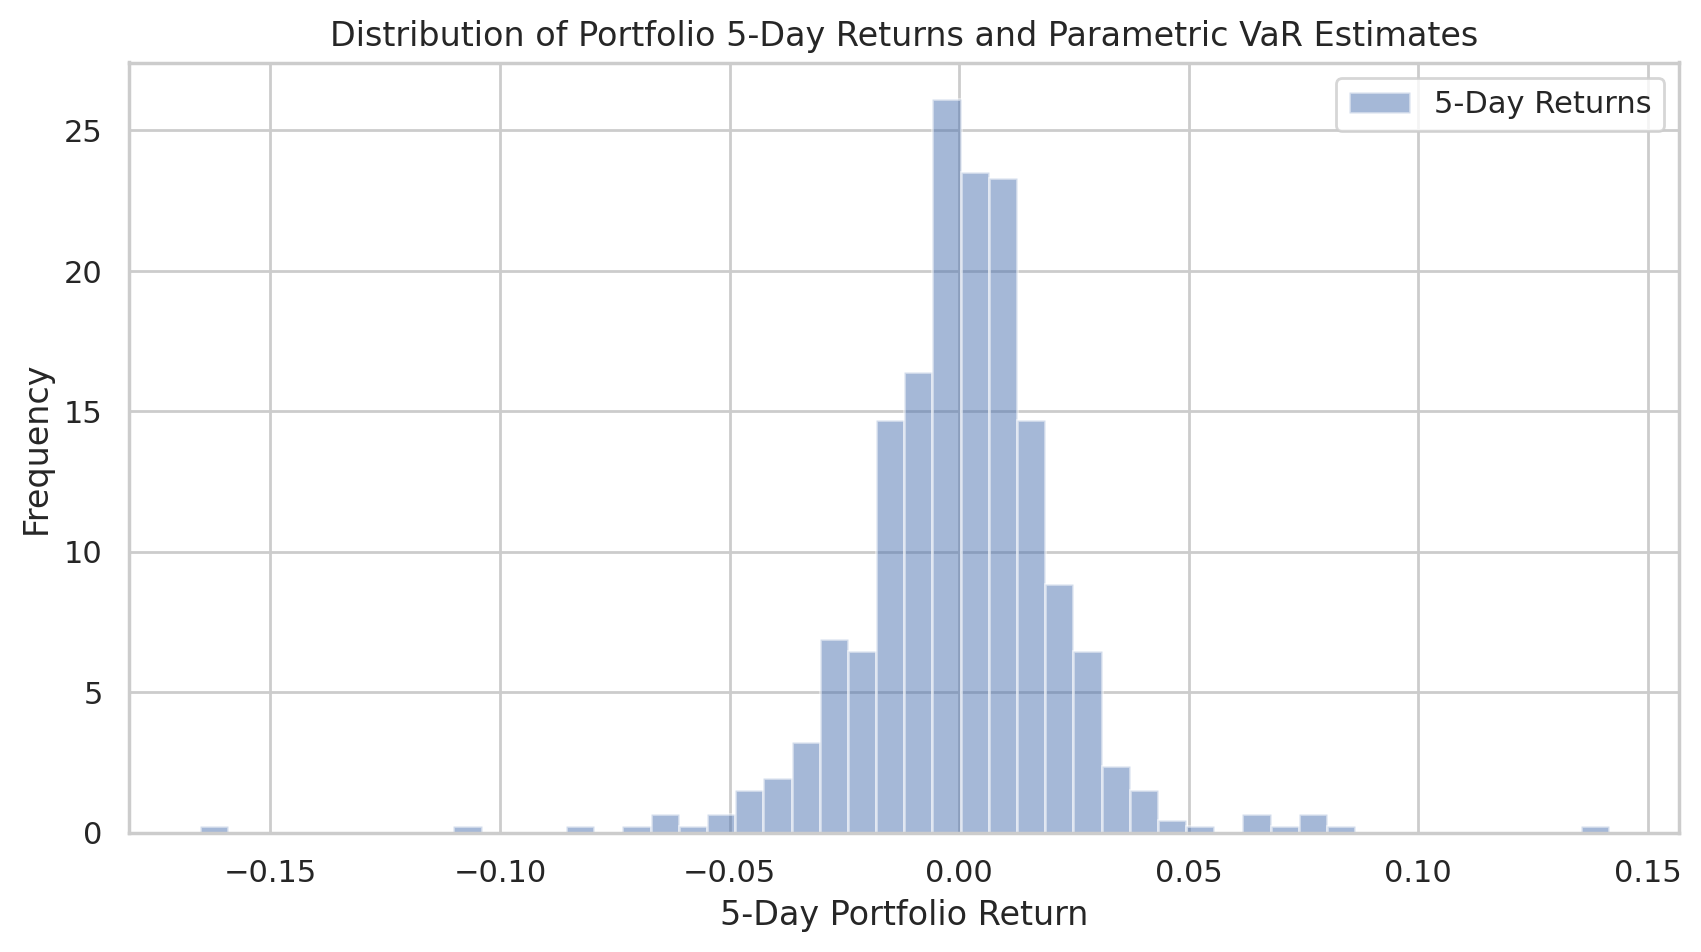

In [ ]:
#We plot the distribution of Portfolio Returns and Parametric VaR estimates

plt.hist(historical_returns, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

plt.xlabel(f'{days}-Day Portfolio Return')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()

# Portfolio 2: Sovereign and corporate bonds

In [ ]:
# Define the assets for the selected income sovereign and corporate bonds
bond_data = {
    'US10Y_DATA': pd.read_csv("/US10Y_202001-202301.csv"),
    'US2Y_DATA': pd.read_csv("/US2Y_202001-202301.csv"),
    'DE10Y_DATA': pd.read_csv("/DE10Y_202001-202301.csv"),
    'CN10Y_DATA': pd.read_csv("/CN10Y_202001-202301.csv"),
    'BAC5Y_DATA': pd.read_csv("/BAC5Y_202001-202301.csv")
}
# Process each DataFrame
for symbol, df in bond_data.items():
    # Convert 'Date' to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort the DataFrame by the 'Date' column
    df.sort_values('Date', inplace=True)

    # Reset the index after sorting
    df.reset_index(drop=True, inplace=True)

    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

In [ ]:
# Extract the Date and Price for each bond into separate DataFrames
us10y_df = bond_data['US10Y_DATA'][['Date', 'Price']].assign(Bond='US10Y')
us2y_df = bond_data['US2Y_DATA'][['Date', 'Price']].assign(Bond='US2Y')
de10y_df = bond_data['DE10Y_DATA'][['Date', 'Price']].assign(Bond='DE10Y')
cn10y_df = bond_data['CN10Y_DATA'][['Date', 'Price']].assign(Bond='CN10Y')
bac5y_df = bond_data['BAC5Y_DATA'][['Date', 'Price']].assign(Bond='BAC5Y')

# Concatenate the individual bond dataframes
combined_bond_data = pd.concat([
    us10y_df,
    us2y_df,
    de10y_df,
    cn10y_df,
    bac5y_df
])
# combined_bond_data.head()

# Pivot the combined dataframe to get the desired format
pivoted_bond_data = combined_bond_data.pivot(index='Date', columns='Bond', values='Price')
pivoted_bond_data.head()

Bond,BAC5Y,CN10Y,DE10Y,US10Y,US2Y
Date,,,,,
2020-01-01,36.64,NaN,NaN,1.921,1.571
2020-01-02,36.54,3.185,-0.221,1.877,1.571
2020-01-03,37.86,3.193,-0.280,1.793,1.533
2020-01-06,38.81,3.178,-0.286,1.809,1.547
2020-01-07,38.82,3.180,-0.283,1.811,1.538


In [ ]:
# Reset the index to make 'Date' a column again if desired
pivoted_bond_data.reset_index(inplace=True)
# pivoted_bond_data.head()

# Rename the columns if you want to remove the top level ('Bond')
pivoted_bond_data.columns.name = None
# pivoted_bond_data.columns = ['Date', 'CN10Y', 'DE10Y', 'US10Y', ]
pivoted_bond_data.head()

,Date,BAC5Y,CN10Y,DE10Y,US10Y,US2Y
0,2020-01-01,36.64,NaN,NaN,1.921,1.571
1,2020-01-02,36.54,3.185,-0.221,1.877,1.571
2,2020-01-03,37.86,3.193,-0.280,1.793,1.533
3,2020-01-06,38.81,3.178,-0.286,1.809,1.547
4,2020-01-07,38.82,3.180,-0.283,1.811,1.538


In [ ]:
pivoted_bond_data.set_index('Date', inplace=True)

       Annual Return  Annual Volatility   Skewness    Kurtosis
BAC5Y       0.441123           0.613063   1.293829    9.244892
CN10Y      -0.022688           0.120128  -0.696920    8.664481
DE10Y      -1.458534           6.835668 -13.653749  291.464276
US10Y       0.476142           0.725804   1.425941   23.709645
US2Y        0.757846           0.949877   0.653340    7.897411


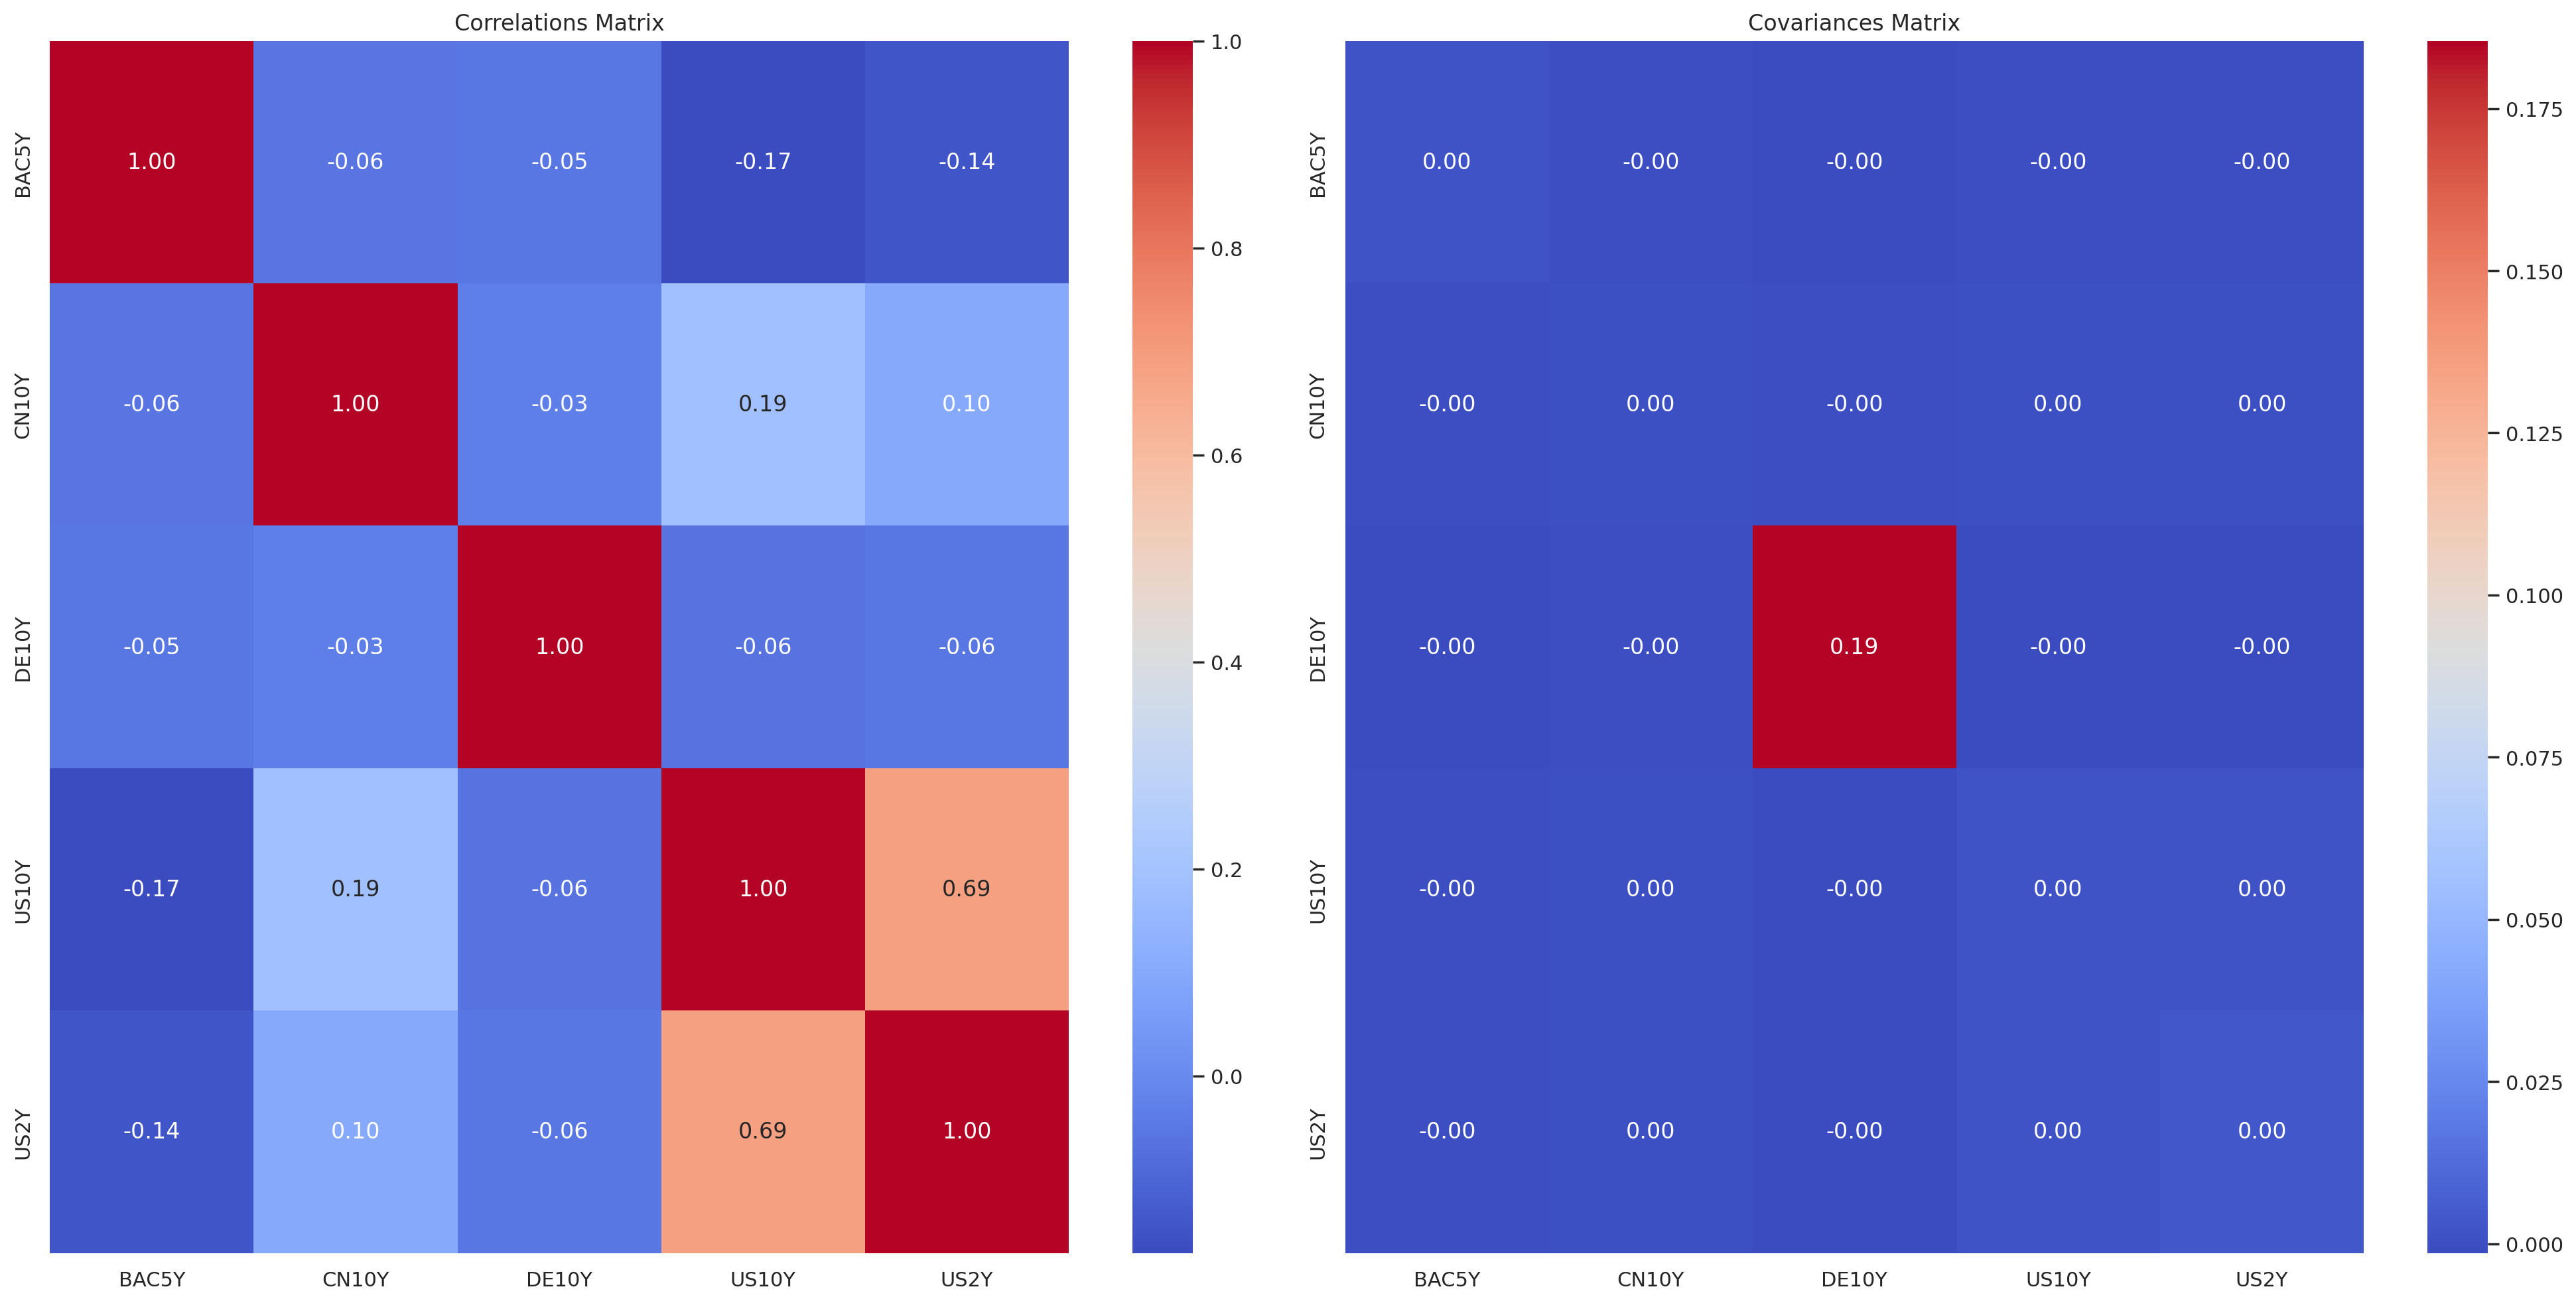

In [ ]:
# Average return
returns = pivoted_bond_data.pct_change().dropna()
# returns.tail()
trading_days = 252
annual_returns = returns.mean() * trading_days
# annual_returns.tail()

# Volatility (standard deviation)
annual_volatility = returns.std() * np.sqrt(trading_days)
# annual_volatility.tail()

# Skewness
skewness = returns.skew()
# skewness.tail()

# Kurtosis
kurtosis = returns.kurtosis()
# kurtosis.tail()

# Create a DataFrame to display results
statistics = pd.DataFrame({
    'Annual Return': annual_returns,
    'Annual Volatility': annual_volatility,
    'Skewness': skewness,
    'Kurtosis': kurtosis
})
print(statistics)

# Correlations among assets within the same portfolio
correlations = returns.corr()

# Covariances among assets within the same portfolio
covariances = returns.cov()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0])
ax[0].set_title("Correlations Matrix")
sns.heatmap(covariances, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1])
ax[1].set_title("Covariances Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate log returns for each cryptocurrency
log_returns = np.log(pivoted_bond_data / pivoted_bond_data.shift(1))

# Drop the first row with NaN values that result from the shift operation
log_returns = log_returns.dropna()

# Show the tail of the log returns DataFrame
log_returns.tail()

/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:329: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,BAC5Y,CN10Y,DE10Y,US10Y,US2Y
Date,,,,,
2022-12-26,0.011434,0.006263,-0.001046,-0.002135,0.001155
2022-12-27,0.000230,0.007602,0.052005,0.027926,0.011704
2022-12-28,-0.000230,-0.004139,-0.003185,0.009567,-0.005950
2022-12-29,0.000115,-0.003810,-0.018106,-0.017130,0.002064
2022-12-30,-0.011433,0.000694,0.039798,0.015327,0.014101


In [ ]:
portfolio_value = 1000000
weights = np.array([0.2, 0.2, 0.2, 0.1, 0.1])
print(weights)

[0.2 0.2 0.2 0.1 0.1]


In [ ]:
historical_returns = (log_returns * weights).sum(axis =1)
historical_returns

Date
2020-01-03    0.047898
2020-01-06    0.010053
2020-01-07   -0.002405
2020-01-08   -0.027388
2020-01-09   -0.032802
                ...   
2022-12-26    0.003232
2022-12-27    0.015930
2022-12-28   -0.001149
2022-12-29   -0.005867
2022-12-30    0.008755
Length: 651, dtype: float64

In [ ]:
#We find the x-day Historical Returns
days = 20
range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2020-02-11   -0.011824
2020-02-12   -0.064306
2020-02-13   -0.069573
2020-02-14   -0.060132
2020-02-17   -0.031790
                ...   
2022-12-26    0.050436
2022-12-27    0.049719
2022-12-28    0.045315
2022-12-29    0.039339
2022-12-30    0.056121
Length: 632, dtype: float64


In [ ]:
#We create a Covariance Matrix and calculate the portfolio standard deviation
cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [ ]:
cov_matrix

,BAC5Y,CN10Y,DE10Y,US10Y,US2Y
BAC5Y,0.390995,-0.004507,-0.013374,-0.110924,-0.113160
CN10Y,-0.004507,0.012836,-0.019935,0.010422,0.006575
DE10Y,-0.013374,-0.019935,6.503050,-0.380458,-0.400560
US10Y,-0.110924,0.010422,-0.380458,0.503166,0.475977
US2Y,-0.113160,0.006575,-0.400560,0.475977,0.983739


In [ ]:
#We calculate VaR at Different Confidence Levels
from scipy.stats import norm

confidence_levels = [0.90, 0.95, 0.99]

VaRs = []
for cl in confidence_levels:
    VaR = portfolio_value * portfolio_std_dev * norm.ppf(cl) * np.sqrt(days / 252)
    VaRs.append(VaR)

In [ ]:
#We get the VaR Results
print(f'{"Confidence Level":<20} {"Value at Risk":<20}')
print('-' * 40)

for cl, VaR in zip(confidence_levels, VaRs):
    print(f'{cl * 100:>6.0f}%: {"":<8} ${VaR:>10,.2f}')

Confidence Level     Value at Risk       
----------------------------------------
    90%:          $183,424.29
    95%:          $235,422.53
    99%:          $332,962.57


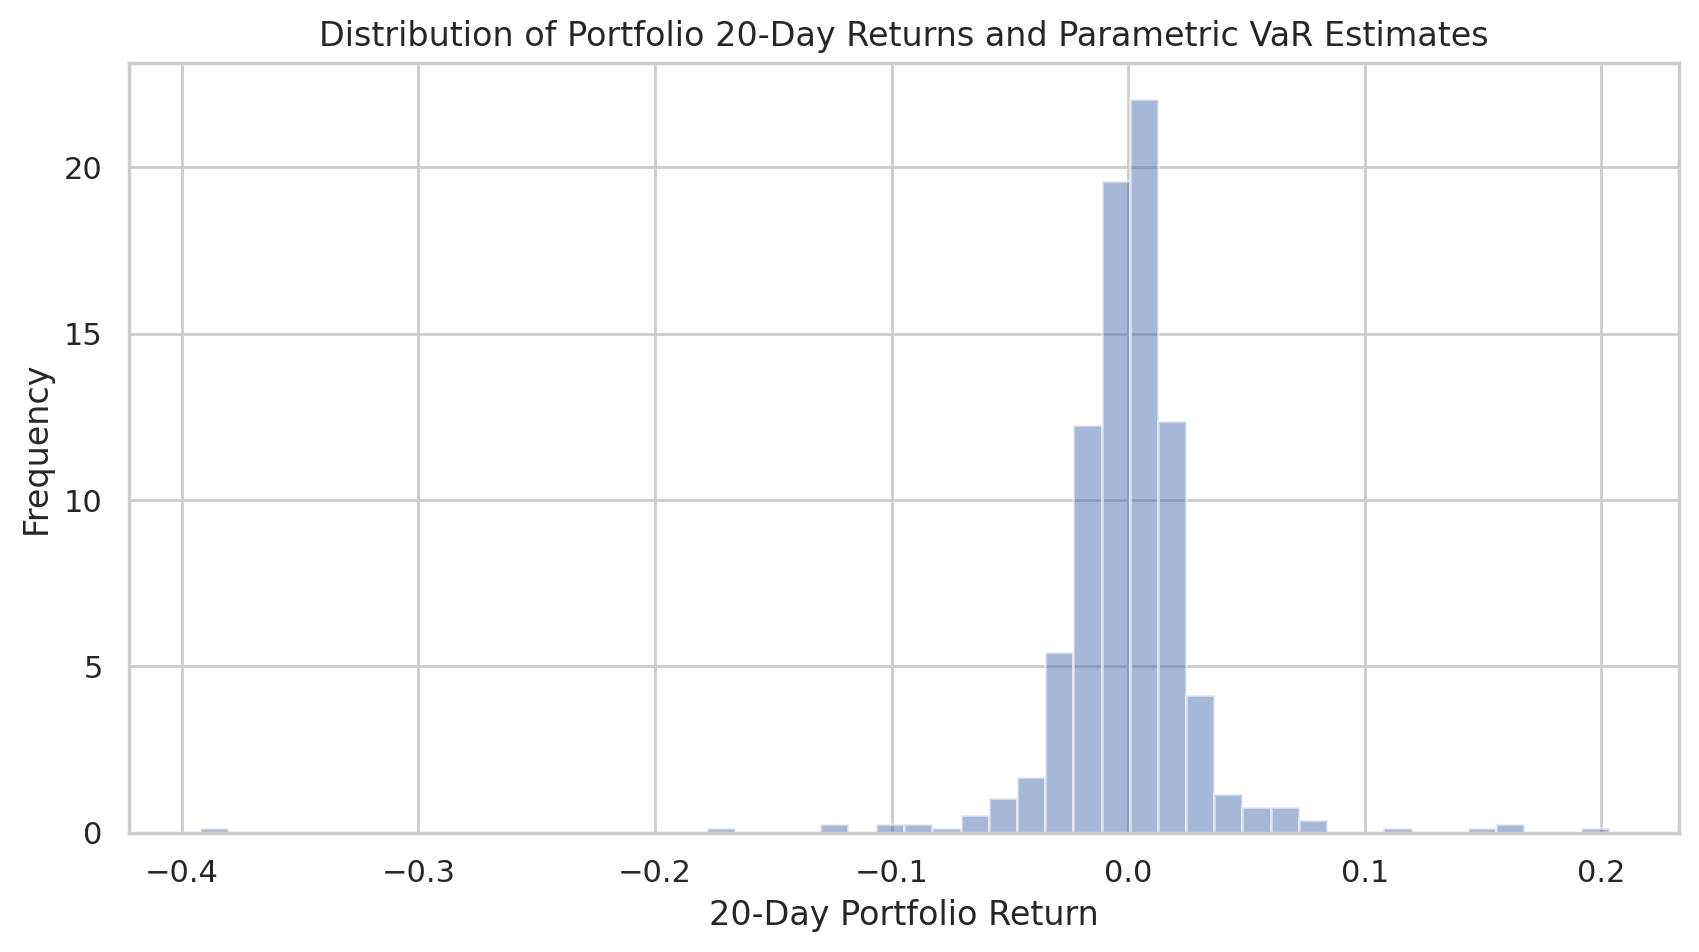

In [ ]:
#We plot the distribution of Portfolio Returns and Parametric VaR estimates
plt.hist(historical_returns, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')
plt.xlabel(f'{days}-Day Portfolio Return')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
# plt.legend()
plt.show()

# Portfolio 3: Cryptocurrencies

In [ ]:
# Define the assets for the selected income cryptocurrencies
assets = ['BTC', 'ETH', 'XRP']

In [ ]:
crypto_data = {
    'BTC': pd.read_csv("https://raw.githubusercontent.com/KhoaLearn/WQU/main/BTC_USD%20Bitfinex%20Historical%20Data.csv"),
    'ETH': pd.read_csv("https://raw.githubusercontent.com/KhoaLearn/WQU/main/ETH_USD%20Binance%20Historical%20Data.csv"),
    'XRP': pd.read_csv("https://raw.githubusercontent.com/KhoaLearn/WQU/main/XRP_USD%20OKX%20Historical%20Data.csv")
}

# Process each DataFrame
for symbol, df in crypto_data.items():
    # Convert 'Date' to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort the DataFrame by the 'Date' column
    df.sort_values('Date', inplace=True)

    # Reset the index after sorting
    df.reset_index(drop=True, inplace=True)

    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

In [ ]:
# Extract the Date and Price for each crypto into separate DataFrames
btc_df = crypto_data['BTC'][['Date', 'Price']].assign(Crypto='BTC')
eth_df = crypto_data['ETH'][['Date', 'Price']].assign(Crypto='ETH')
xrp_df = crypto_data['XRP'][['Date', 'Price']].assign(Crypto='XRP')

# Concatenate the individual crypto dataframes
combined_crypto_data = pd.concat([
    btc_df,
    eth_df,
    xrp_df
])

# Pivot the combined dataframe to get the desired format
pivoted_crypto_data = combined_crypto_data.pivot(index='Date', columns='Crypto', values='Price')


pivoted_crypto_data.reset_index(inplace=True)

pivoted_crypto_data.columns.name = None
pivoted_crypto_data.columns = ['Date', 'BTC', 'ETH', 'XRP']

pivoted_crypto_data.tail()

,Date,BTC,ETH,XRP
1092,2022-12-28,16558.0,1189.93,0.35575
1093,2022-12-29,16658.0,1200.80,0.34198
1094,2022-12-30,16618.0,1199.99,0.34516
1095,2022-12-31,16564.0,1195.65,0.33899
1096,2023-01-01,16643.0,1200.51,0.33866


In [ ]:
pivoted_crypto_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1097 non-null   datetime64[ns]
 1   BTC     1097 non-null   float64       
 2   ETH     1092 non-null   float64       
 3   XRP     1096 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 34.4 KB


In [ ]:
btc = crypto_data['BTC']
eth = crypto_data['ETH']
xrp = crypto_data['XRP']

In [ ]:
# btc['Price'] = btc['Price'].str.replace(',', '').astype(float)
# eth['Price'] = eth['Price'].str.replace(',', '').astype(float)
# xrp['Price'] = xrp['Price'].str.replace(',', '').astype(float)

In [ ]:
# Convert 'Date' columns to datetime
btc['Date'] = pd.to_datetime(btc['Date'])
eth['Date'] = pd.to_datetime(eth['Date'])
xrp['Date'] = pd.to_datetime(xrp['Date'])

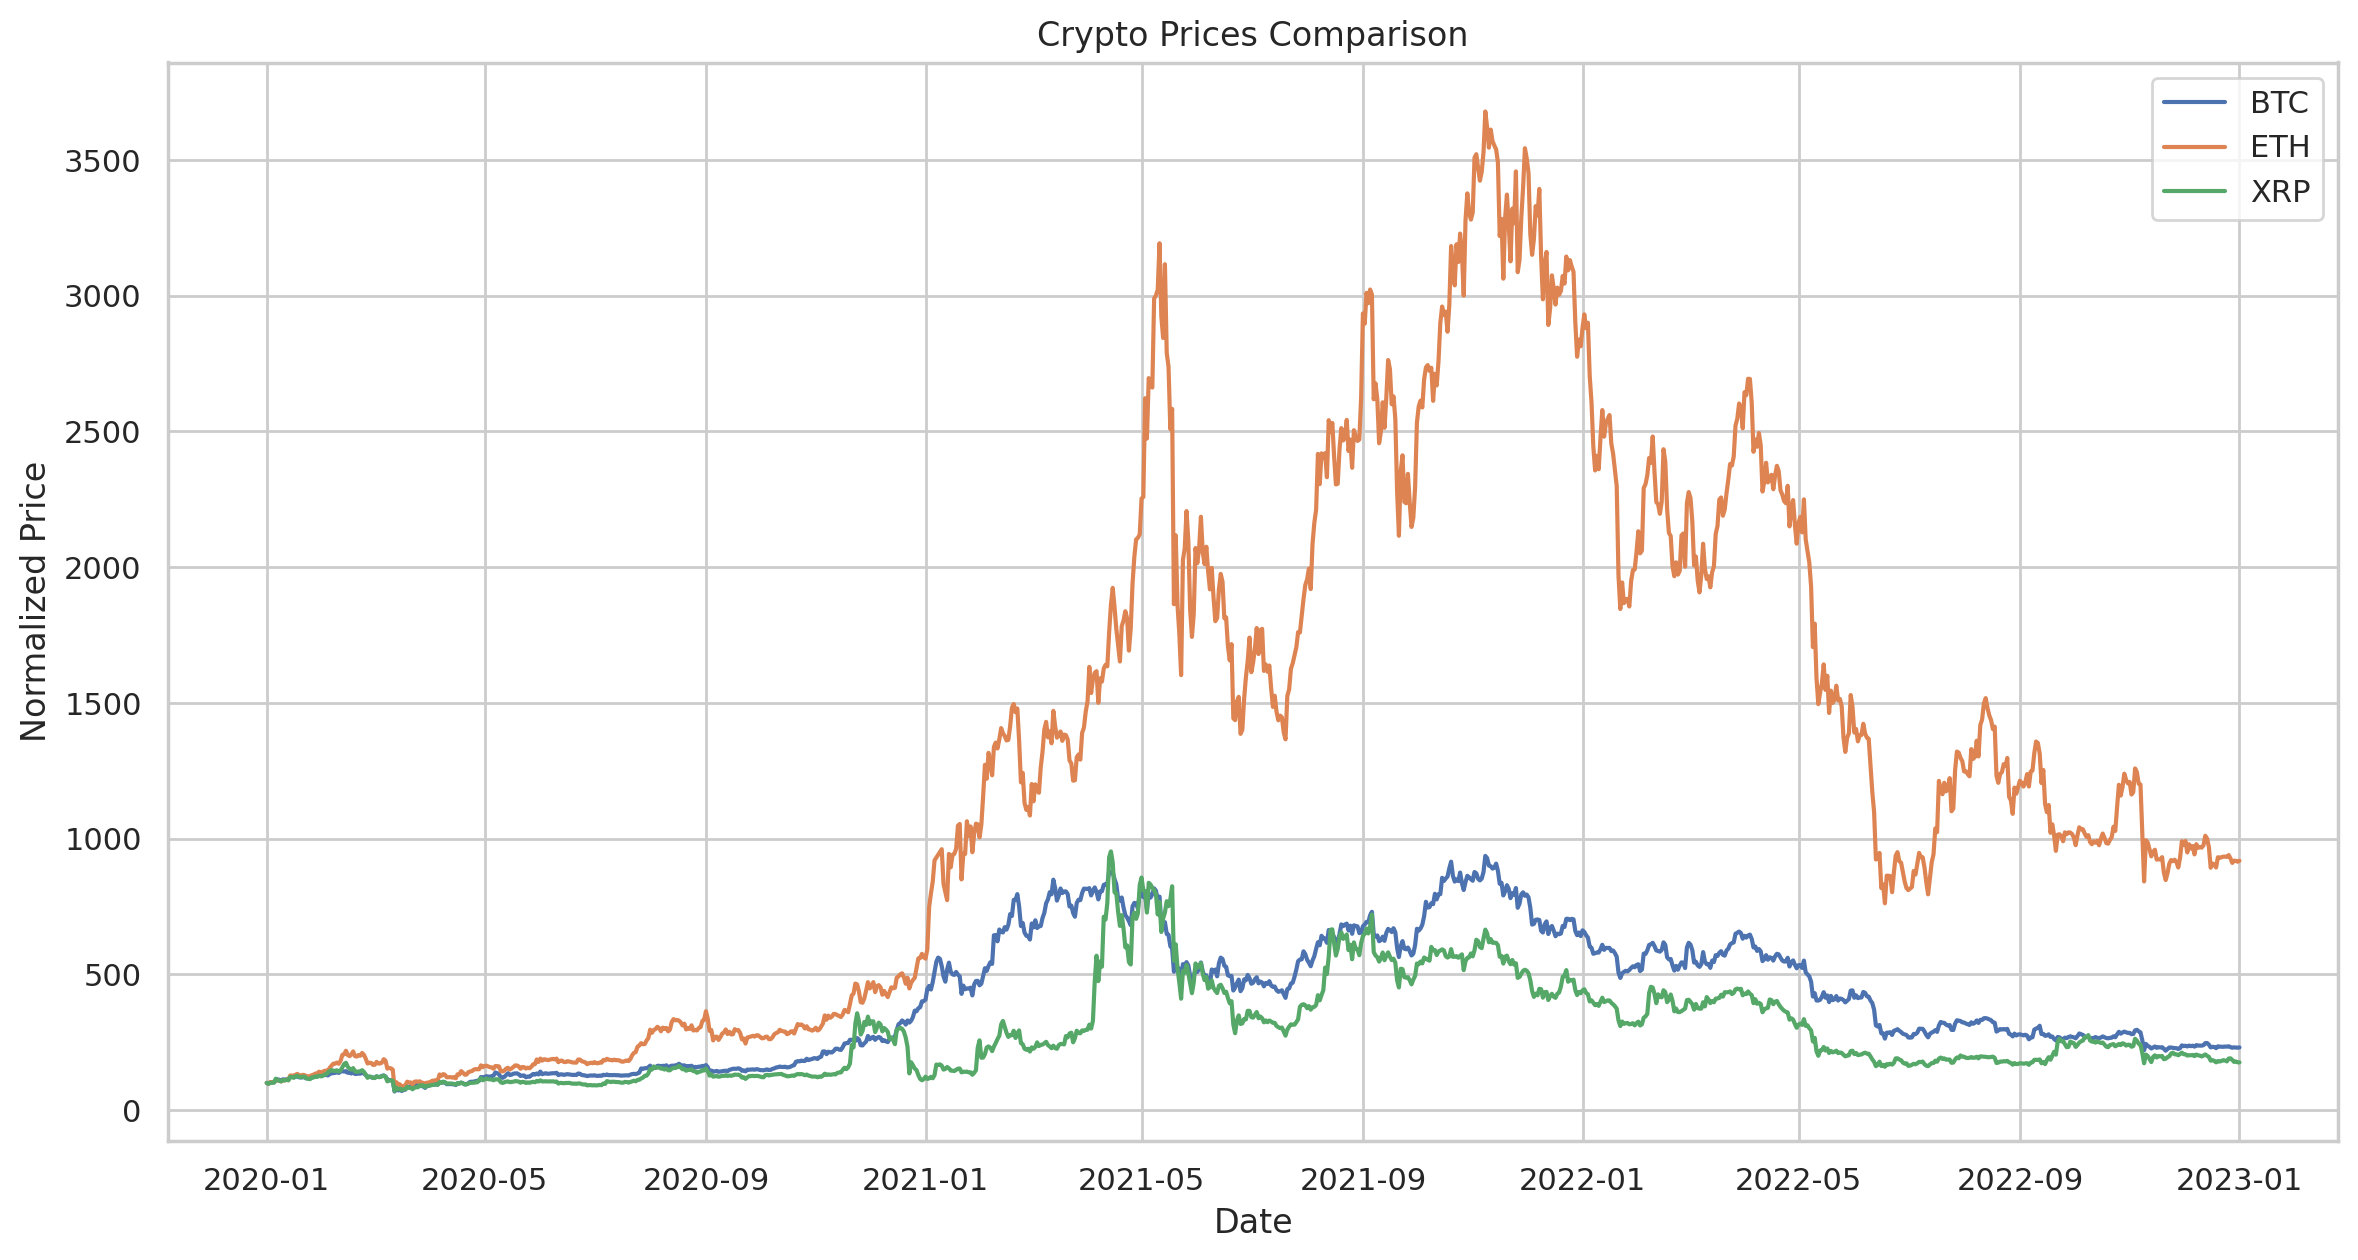

In [ ]:
# Normalize the prices for comparison
btc['Normalized'] = btc['Price'] / btc['Price'].iloc[0] * 100
eth['Normalized'] = eth['Price'] / eth['Price'].iloc[0] * 100
xrp['Normalized'] = xrp['Price'] / xrp['Price'].iloc[0] * 100

# Plot the normalized prices
plt.figure(figsize=(14, 7))

plt.plot(btc['Date'], btc['Normalized'], label='BTC')
plt.plot(eth['Date'], eth['Normalized'], label='ETH')
plt.plot(xrp['Date'], xrp['Normalized'], label='XRP')

# Add annotations, titles, legend, etc.
plt.title('Crypto Prices Comparison')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

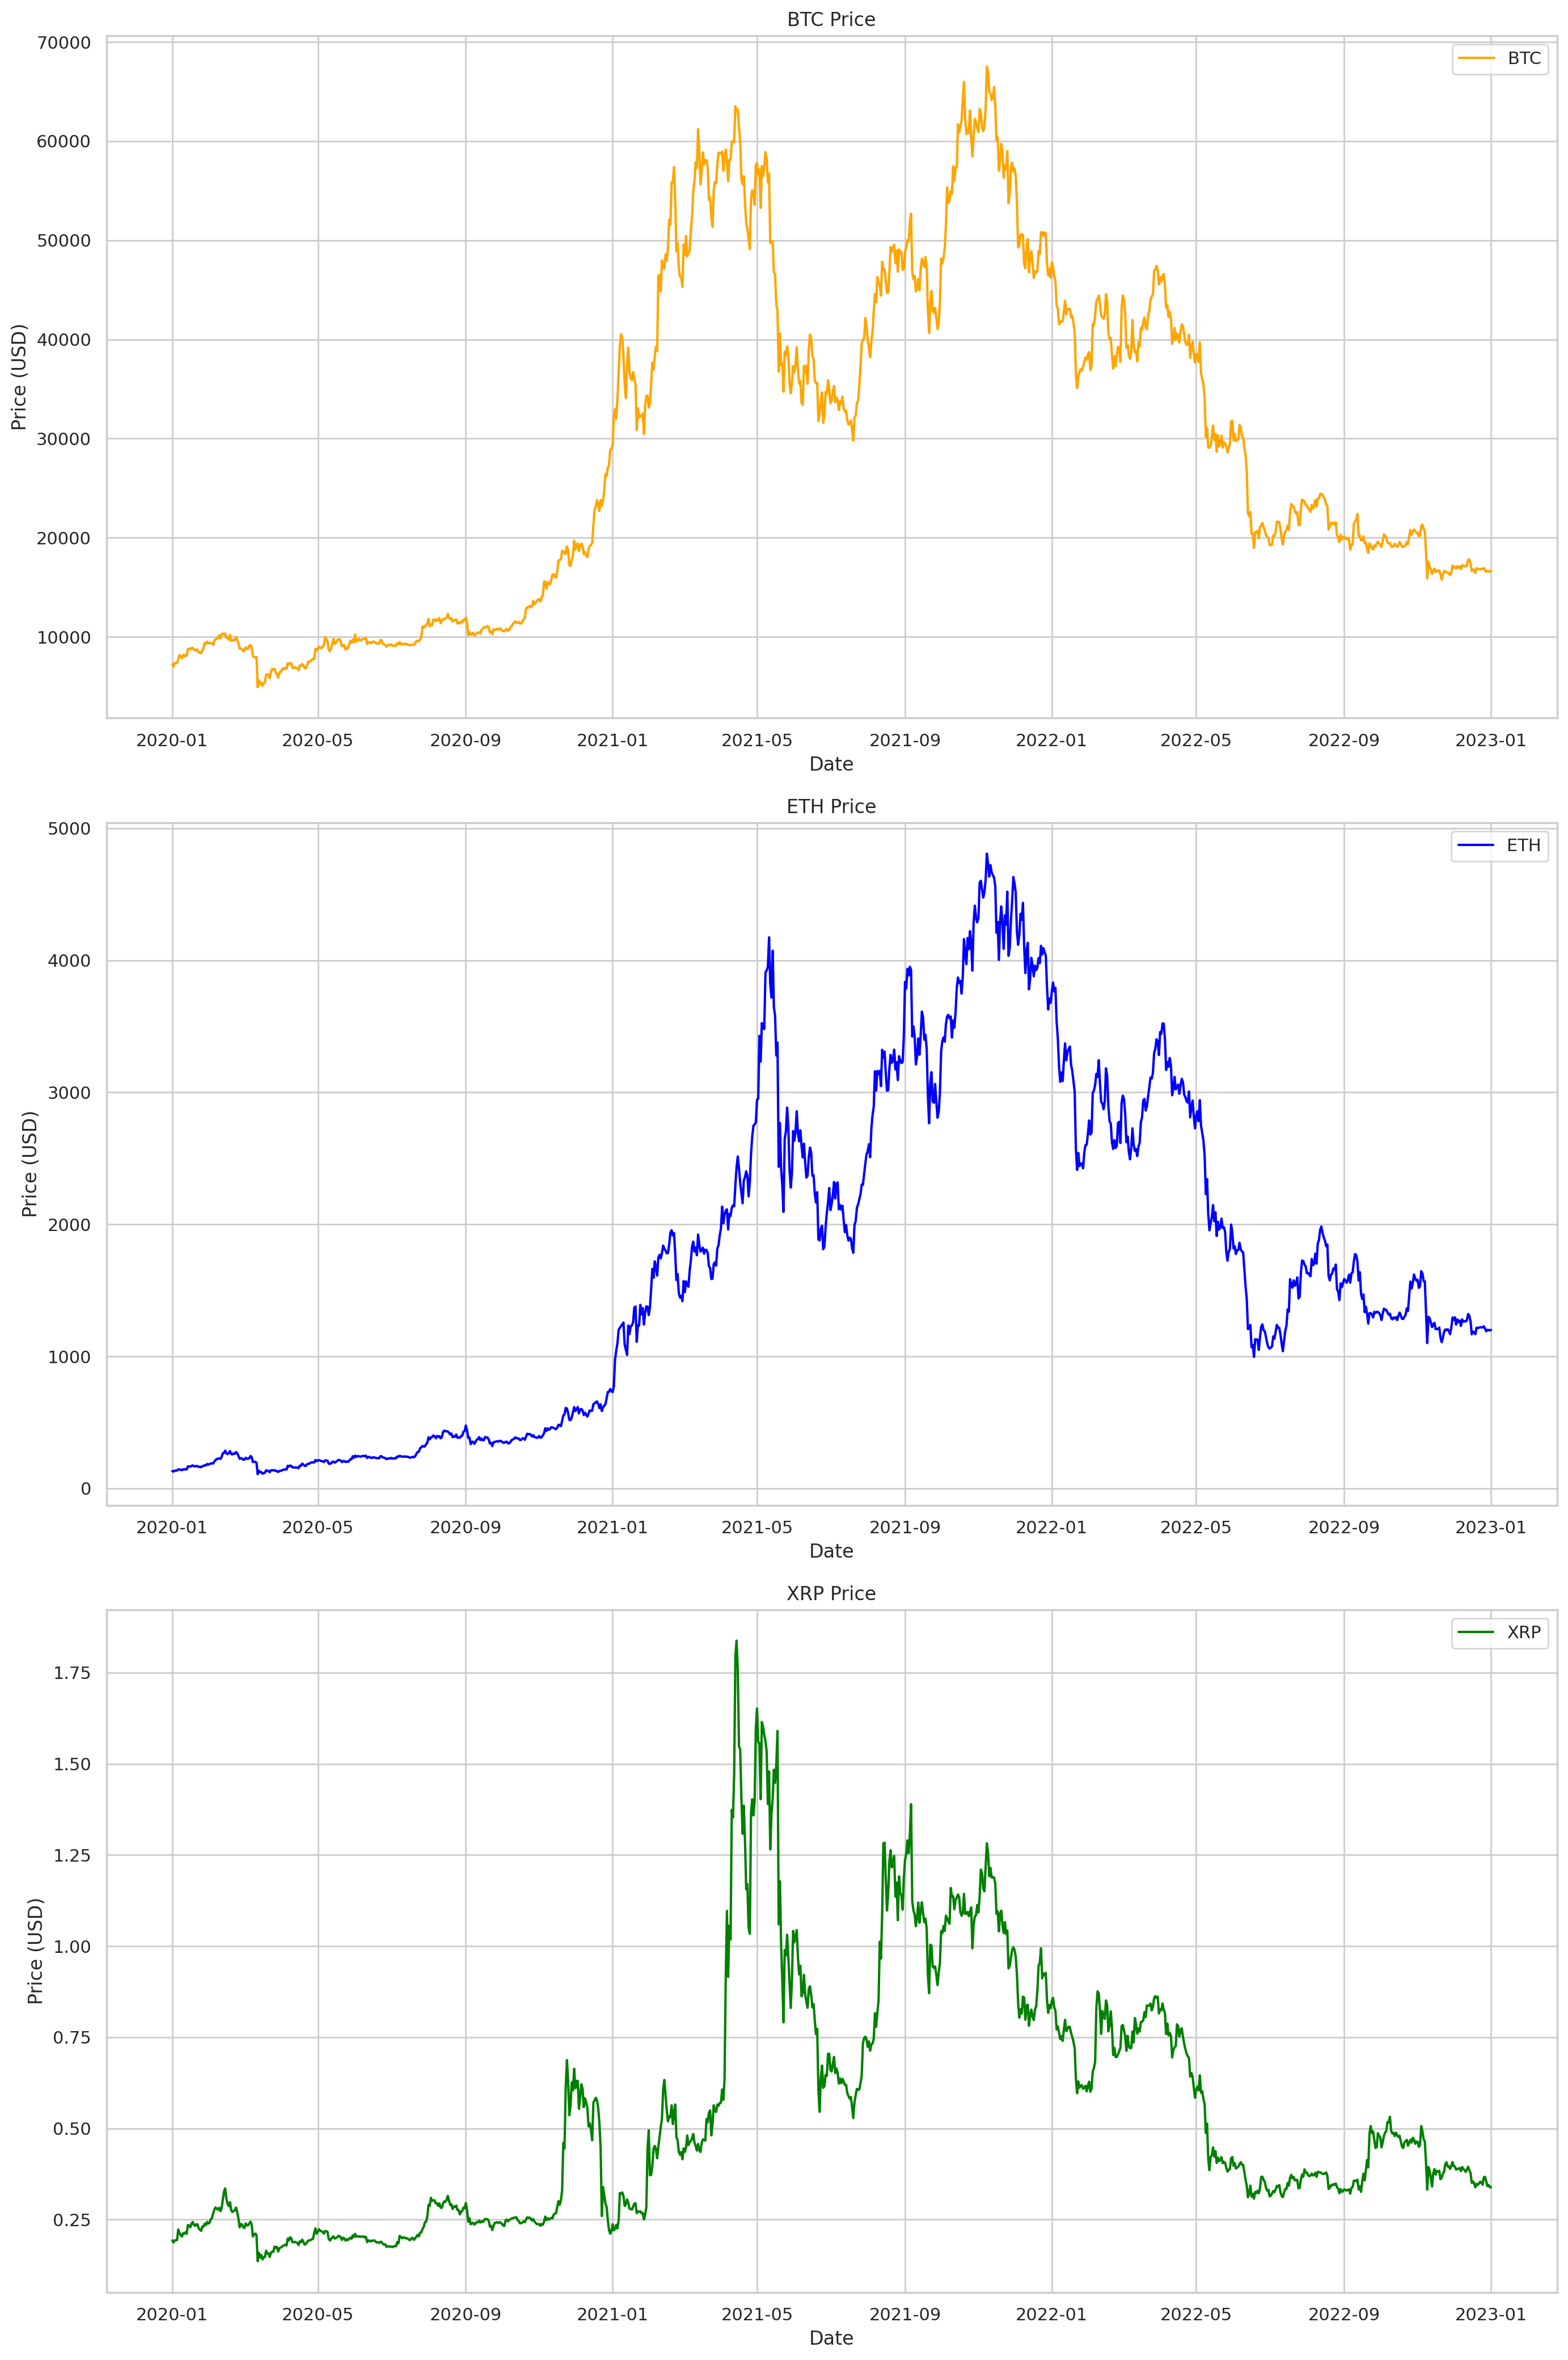

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(14, 21))

# Plot BTC prices
axs[0].plot(btc['Date'], btc['Price'], label='BTC', color='orange')
axs[0].set_title('BTC Price')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()

# Plot ETH prices
axs[1].plot(eth['Date'], eth['Price'], label='ETH', color='blue')
axs[1].set_title('ETH Price')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()

# Plot XRP prices
axs[2].plot(xrp['Date'], xrp['Price'], label='XRP', color='green')
axs[2].set_title('XRP Price')
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Price (USD)')
axs[2].legend()

# Automatically adjust subplot params so that the subplot(s) fits in to the figure area
plt.tight_layout()
plt.show()

In [ ]:
pivoted_crypto_data.head()

,Date,BTC,ETH,XRP
0,2020-01-01,7212.7,130.71,0.1929
1,2020-01-02,6989.4,127.07,0.1875
2,2020-01-03,7367.5,134.37,0.1933
3,2020-01-04,7369.8,134.17,0.1931
4,2020-01-05,7364.6,135.42,0.1946


In [ ]:
pivoted_crypto_data.set_index('Date', inplace=True)

# Calculate returns (simple returns) for each cypto
returns = pivoted_crypto_data.pct_change().dropna()

# Show the tail of the returns DataFrame
returns.tail()

,BTC,ETH,XRP
Date,,,
2022-12-28,-0.009630,-0.017845,-0.031867
2022-12-29,0.006039,0.009135,-0.038707
2022-12-30,-0.002401,-0.000675,0.009299
2022-12-31,-0.003249,-0.003617,-0.017876
2023-01-01,0.004769,0.004065,-0.000973


In [ ]:
# Annualize the returns and volatility if the data is daily
trading_days = 365
annual_returns = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)
skewness = returns.skew()
kurtosis = returns.kurtosis()

In [ ]:
# Create a DataFrame to display results
annual_statistics = pd.DataFrame({
    'Annual Return': annual_returns,
    'Annual Volatility': annual_volatility
})

# Display the DataFrame
print(annual_statistics)

     Annual Return  Annual Volatility
BTC       0.383594           0.609552
ETH       0.859648           0.824959
XRP       0.633218           1.017885


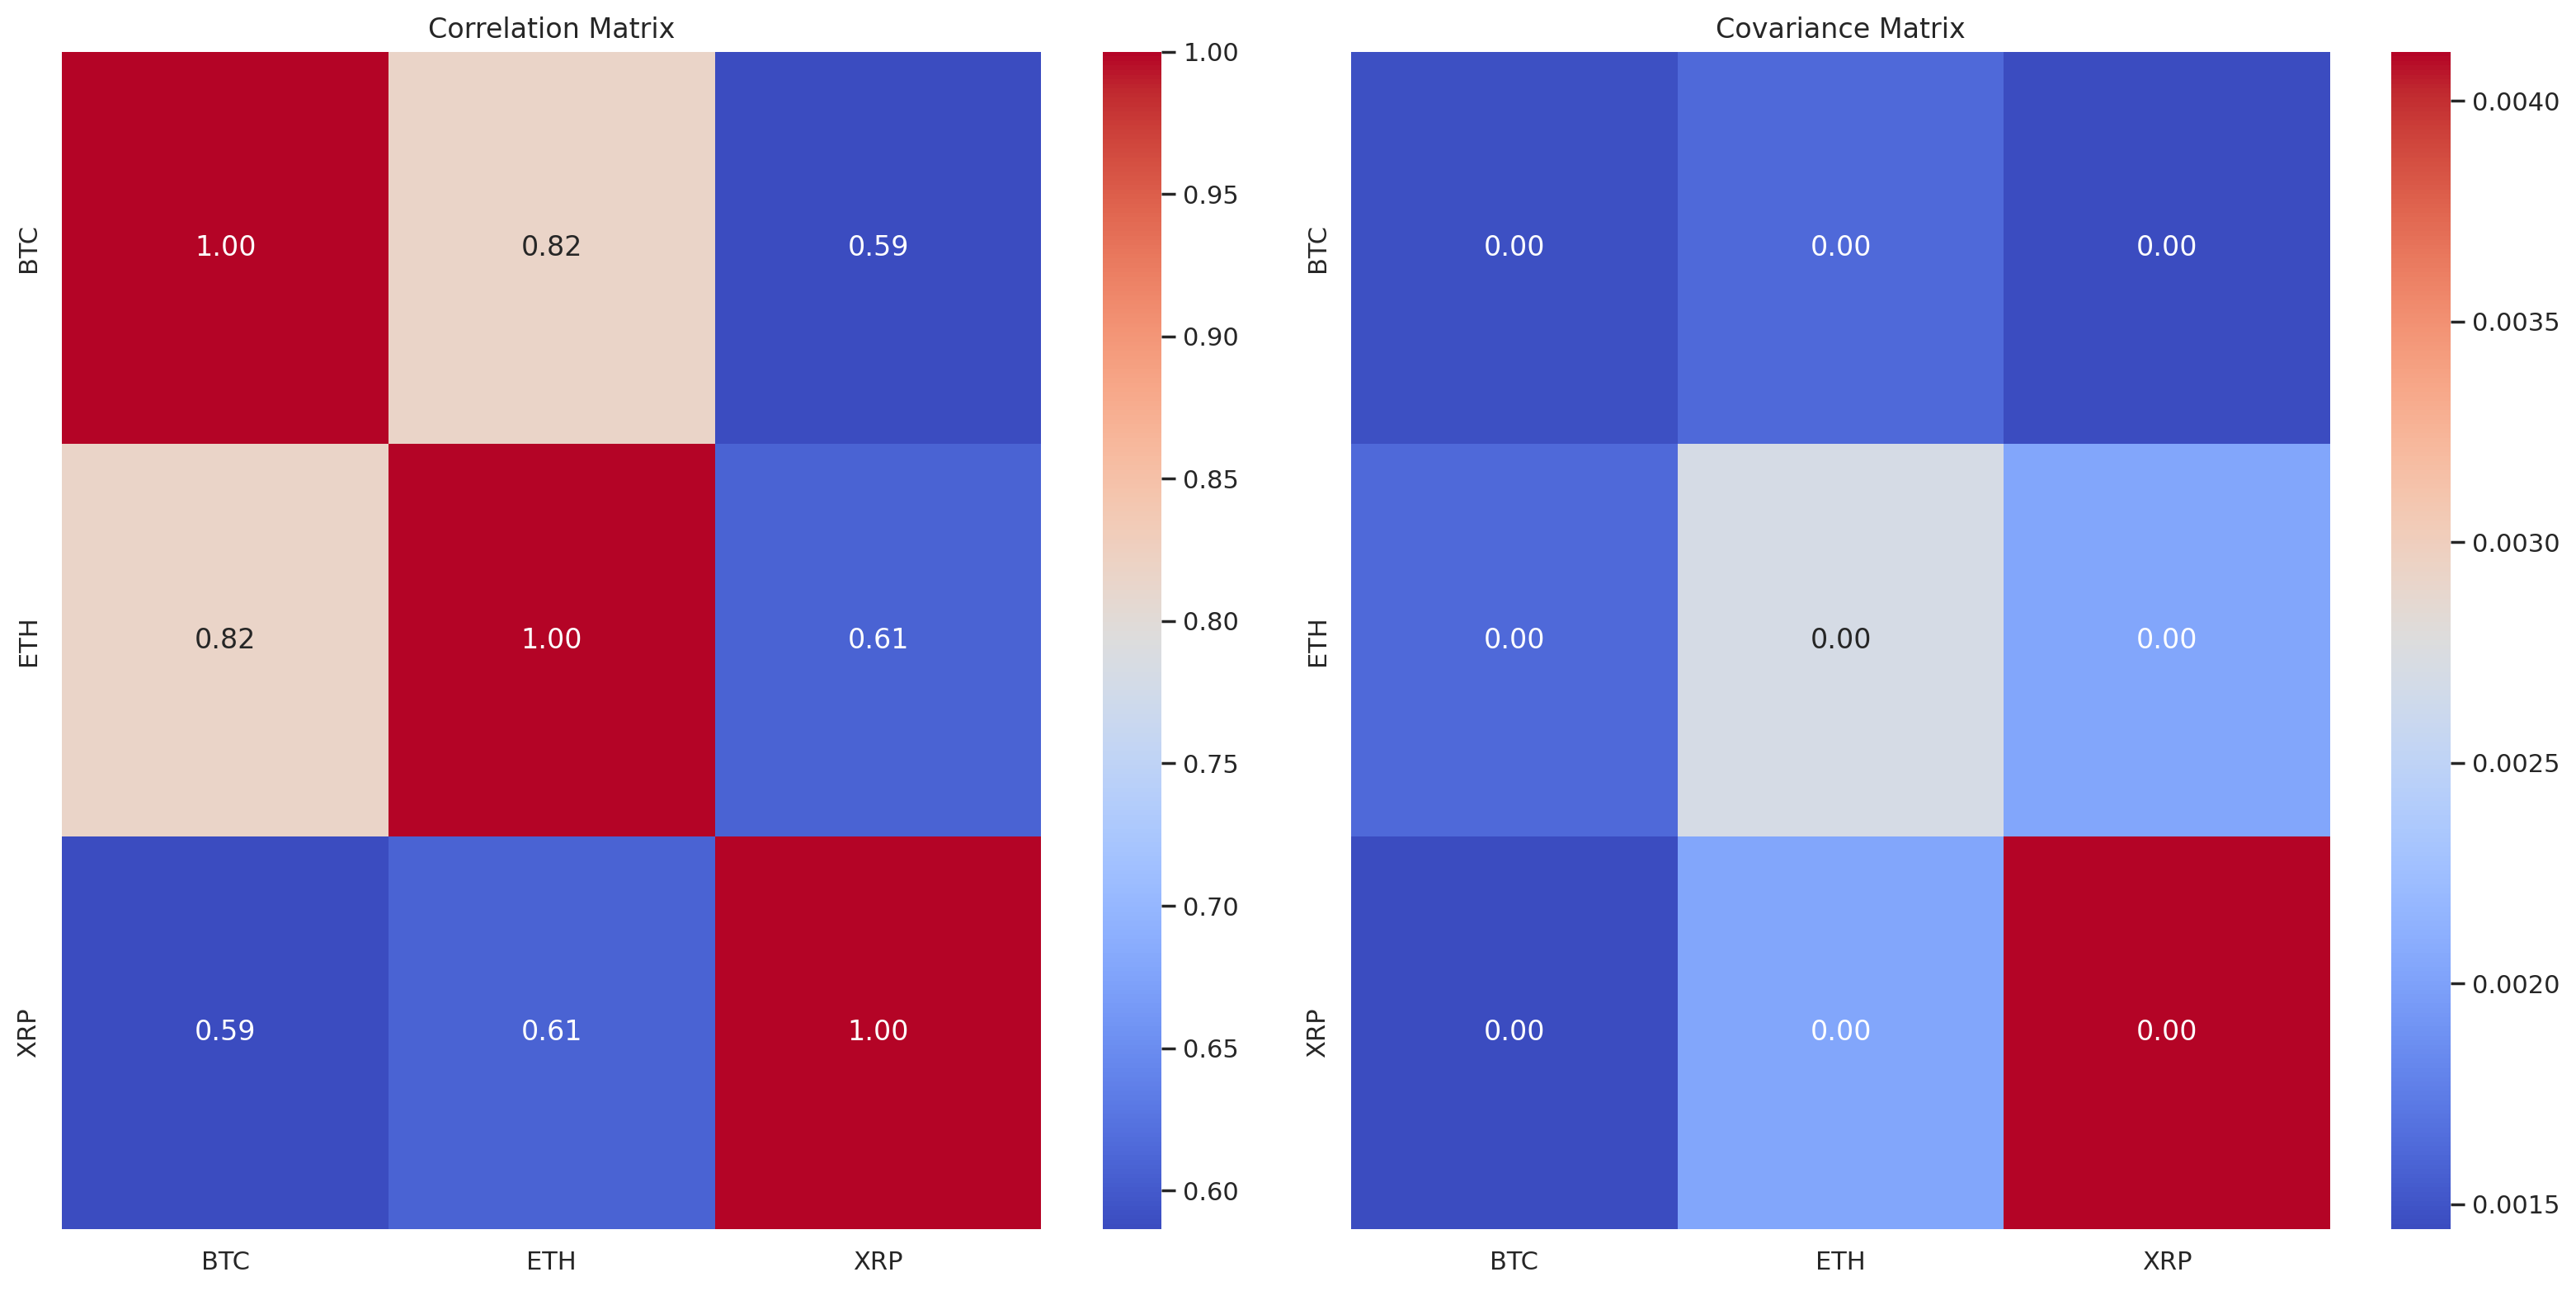

In [ ]:
# Calculate correlations and covariances among the stocks
correlations = returns.corr()
covariances = returns.cov()

# Set up the matplotlib figure
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Draw the heatmap for correlations
sns.heatmap(correlations, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0])
ax[0].set_title('Correlation Matrix')

# Draw the heatmap for covariances
sns.heatmap(covariances, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1])
ax[1].set_title('Covariance Matrix')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
returns.describe()

,BTC,ETH,XRP
count,1096.000000,1096.000000,1096.000000
mean,0.001522,0.003411,0.002513
std,0.038398,0.051968,0.064121
min,-0.381776,-0.447032,-0.418511
25%,-0.015839,-0.021214,-0.023672
50%,0.001013,0.002679,0.001361
75%,0.019145,0.029766,0.024216
max,0.195644,0.264635,0.570570


In [ ]:
# Output the results
print("Average Return:\n", annual_returns)
print("\nVolatility:\n", annual_volatility)
print("\nSkewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)
print("\nCorrelations:\n", correlations)
print("\nCovariances:\n", covariances)

Average Return:
 BTC    0.383594
ETH    0.859648
XRP    0.633218
dtype: float64

Volatility:
 BTC    0.609552
ETH    0.824959
XRP    1.017885
dtype: float64

Skewness:
 BTC   -0.757178
ETH   -0.373377
XRP    1.327285
dtype: float64

Kurtosis:
 BTC    10.878126
ETH     8.027659
XRP    15.161942
dtype: float64

Correlations:
           BTC       ETH       XRP
BTC  1.000000  0.817242  0.586553
ETH  0.817242  1.000000  0.609132
XRP  0.586553  0.609132  1.000000

Covariances:
           BTC       ETH       XRP
BTC  0.001474  0.001631  0.001444
ETH  0.001631  0.002701  0.002030
XRP  0.001444  0.002030  0.004111


In [ ]:
# Calculate log returns for each cryptocurrency
log_returns = np.log(pivoted_crypto_data / pivoted_crypto_data.shift(1))

# Drop the first row with NaN values that result from the shift operation
log_returns = log_returns.dropna()

# Show the tail of the log returns DataFrame
log_returns.tail()

,BTC,ETH,XRP
Date,,,
2022-12-28,-0.009676,-0.018006,-0.032386
2022-12-29,0.006021,0.009094,-0.039476
2022-12-30,-0.002404,-0.000675,0.009256
2022-12-31,-0.003255,-0.003623,-0.018037
2023-01-01,0.004758,0.004056,-0.000974


In [ ]:
portfolio_value = 1000000
weights = np.array([1/len(assets)]*len(assets))
print(weights)

[0.33333333 0.33333333 0.33333333]


In [ ]:
historical_returns = (log_returns * weights).sum(axis =1)
historical_returns

Date
2020-01-02   -0.029362
2020-01-03    0.046336
2020-01-04   -0.000738
2020-01-05    0.005435
2020-01-06    0.083264
                ...   
2022-12-28   -0.020023
2022-12-29   -0.008120
2022-12-30    0.002059
2022-12-31   -0.008305
2023-01-01    0.002614
Length: 1087, dtype: float64

In [ ]:
#We find the x-day Historical Returns

days = 5

range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2020-01-06    0.104936
2020-01-07    0.133785
2020-01-08    0.067958
2020-01-09    0.046322
2020-01-10    0.087070
                ...   
2022-12-28   -0.011850
2022-12-29   -0.018856
2022-12-30   -0.010333
2022-12-31   -0.041786
2023-01-01   -0.031776
Length: 1083, dtype: float64


In [ ]:
#We create a Covariance Matrix and calculate the portfolio standard deviation

cov_matrix = log_returns.cov() * 365
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [ ]:
cov_matrix

,BTC,ETH,XRP
BTC,0.391281,0.444374,0.384092
ETH,0.444374,0.717062,0.549326
XRP,0.384092,0.549326,0.996733


In [ ]:
#We calculate VaR at Different Confidence Levels

from scipy.stats import norm

confidence_levels = [0.90, 0.95, 0.99]

VaRs = []
for cl in confidence_levels:
    VaR = portfolio_value * portfolio_std_dev * norm.ppf(cl) * np.sqrt(days / 252)
    VaRs.append(VaR)

In [ ]:
#We get the VaR Results

print(f'{"Confidence Level":<20} {"Value at Risk":<20}')
print('-' * 40)

for cl, VaR in zip(confidence_levels, VaRs):
    print(f'{cl * 100:>6.0f}%: {"":<8} ${VaR:>10,.2f}')

Confidence Level     Value at Risk       
----------------------------------------
    90%:          $132,662.21
    95%:          $170,270.10
    99%:          $240,816.26


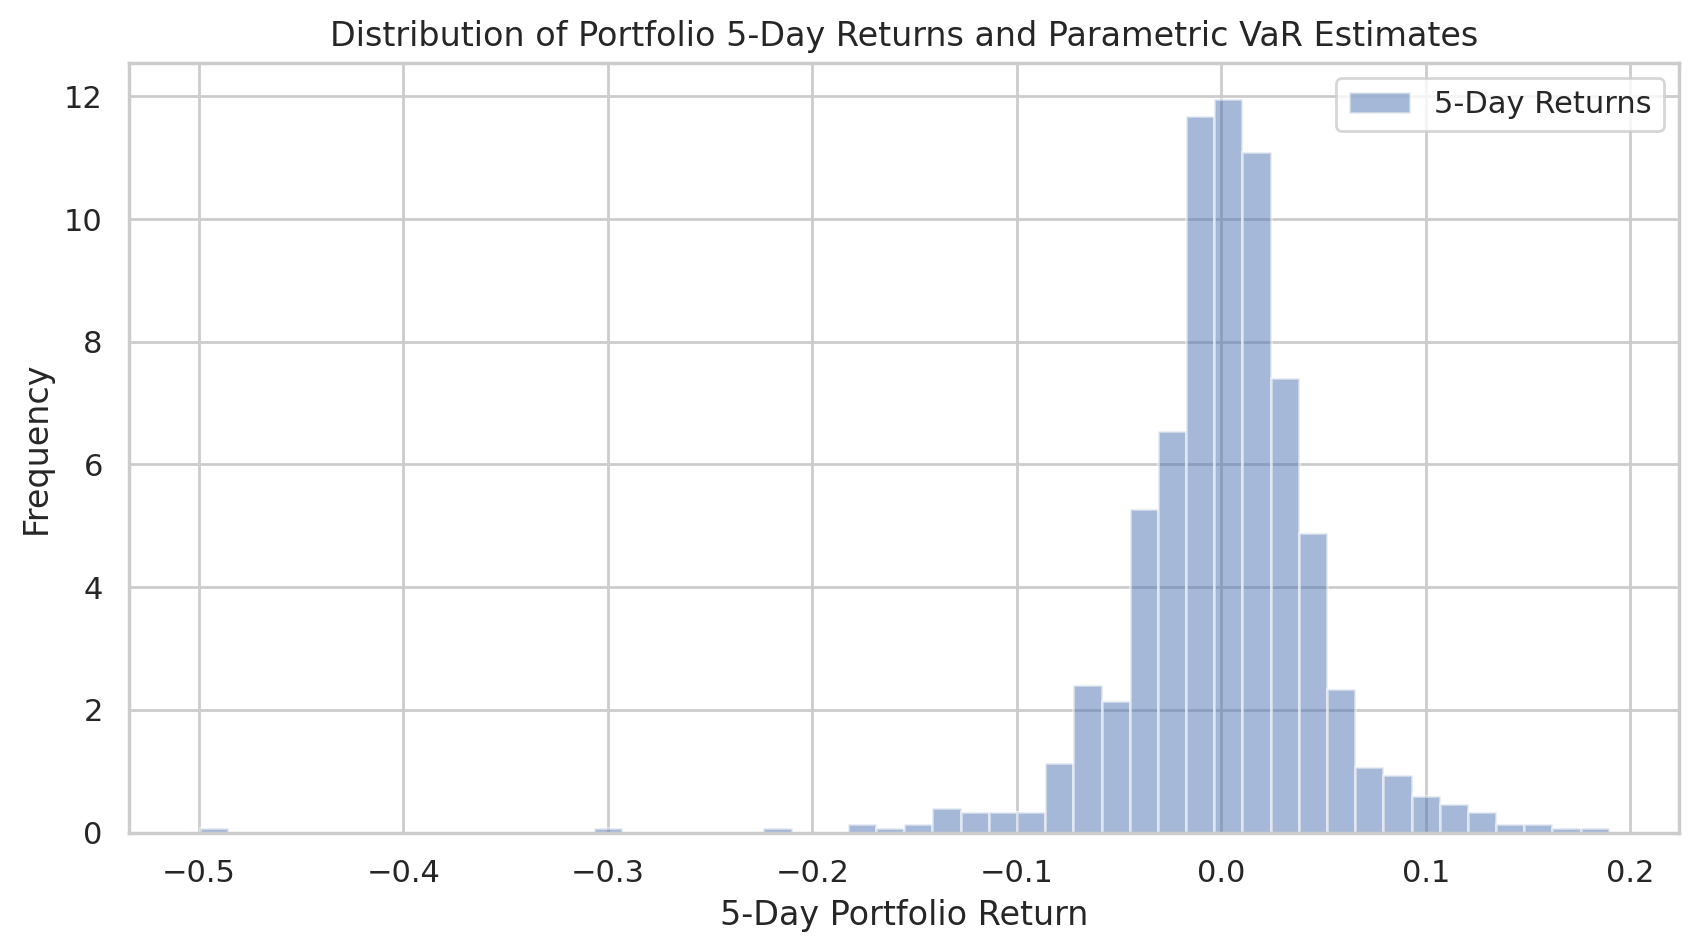

In [ ]:
#We plot the distribution of Portfolio Returns and Parametric VaR estimates

plt.hist(historical_returns, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

plt.xlabel(f'{days}-Day Portfolio Return')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()